# EDA EEG Analysis for Seizure Control Evaluation
This notebook presents an exploratory data analysis (EDA) of EEG data collected from patients undergoing brain stimulation for seizure control. The analysis aims to identify patterns and insights that could inform the effectiveness of stimulation protocols.

In [9]:
import mne
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Loading

In [2]:
# Load all the EEG data files
awake_60hz = mne.io.read_raw_edf('../data/XU/XUAWAKE60.EDF', preload=True)
sleep_60hz = mne.io.read_raw_edf('../data/XU/XUSLEEP60.EDF', preload=True)

# Load 7Hz and T100 files if needed
awake_7hz = mne.io.read_raw_edf('../data/XU/XUAWAKE7.EDF', preload=True)
sleep_7hz = mne.io.read_raw_edf('../data/XU/XUSLEEP7.EDF', preload=True)
awake_t100 = mne.io.read_raw_edf('../data/XU/XUAWAKET100.EDF', preload=True)
sleep_t100 = mne.io.read_raw_edf('../data/XU/XUSLEEPT100.EDF', preload=True)

Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE60.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 156159  =      0.000 ...   609.996 secs...
Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUSLEEP60.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 165375  =      0.000 ...   645.996 secs...
Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUAWAKE7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 145407  =      0.000 ...   567.996 secs...
Extracting EDF parameters from /Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/data/XU/XUSLEEP7.EDF...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 163327  =      0.000 

## Data Preprocessing

In [3]:
def preprocess_eeg(raw):
    # apply band-pass filter (1-45hz is typical for EEG)
    filtered = raw.copy().filter(1., 45.)
    
    # TODO: need to handle bad channels if any are identified (what is the montage?1020?)
    
    # Notch filter to remove power line noise at 50Hz and 60Hz
    filtered.notch_filter(freqs=[50, 60])
    
    return filtered

In [4]:
awake_60hz_clean = preprocess_eeg(awake_60hz)
sleep_60hz_clean = preprocess_eeg(sleep_60hz)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1691 samples (6.605 s)

Filtering raw data in 

## Feature Extraction

### Spectral Features

In [5]:
def analyze_spectral_features(raw):
    # calculate power spectral density (PSD)
    psds, freqs = raw.compute_psd(method='welch', fmin=1, fmax=45, n_fft=2048).get_data(return_freqs=True)
    
    bands = {
        'delta': (1, 4),
        'theta': (4, 8),
        'alpha': (8, 12),
        'beta': (12, 30),
        'gamma': (30, 45)
    }
    
    band_powers = {}
    for band, (fmin, fmax) in bands.items():
        idx_band = (freqs >= fmin) & (freqs <= fmax)
        band_power = psds[:, idx_band].mean(axis=1)
        band_powers[band] = band_power
        
    return band_powers, psds

In [6]:
awake_60hz_powers, awake_60hz_psd = analyze_spectral_features(awake_60hz_clean)
sleep_60hz_powers, sleep_60hz_psd = analyze_spectral_features(sleep_60hz_clean)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/698032666.py:3: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(method='welch', fmin=1, fmax=45, n_fft=2048).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/698032666.py:3: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(method='welch', fmin=1, fmax=45, n_fft=2048).get_data(return_freqs=True)


In [7]:
def plot_band_powers(awake_powers, sleep_powers):
    bands = list(awake_powers.keys())
    awake_means = [awake_powers[band].mean() for band in bands]
    sleep_means = [sleep_powers[band].mean() for band in bands]
    
    x = range(len(bands))
    width = 0.35
    
    plt.bar(x, awake_means, width, label='Awake', color='b', alpha=0.6)
    plt.bar([p + width for p in x], sleep_means, width, label='Sleep', color='r', alpha=0.6)
    
    plt.xticks([p + width/2 for p in x], bands)
    plt.ylabel('Mean Power')
    plt.title('Mean Band Powers: Awake vs Sleep')
    plt.legend()
    plt.show()

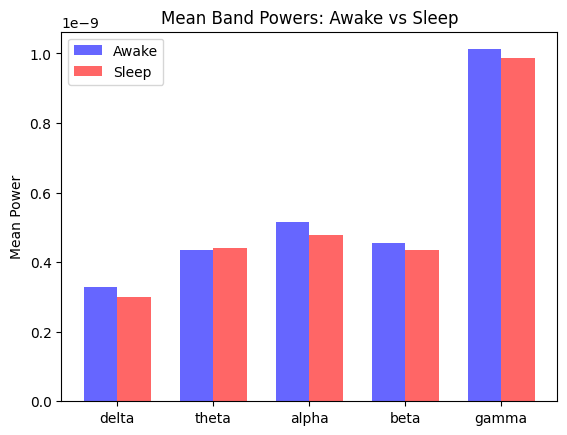

In [8]:
plot_band_powers(awake_60hz_powers, sleep_60hz_powers)

## Seizure activity detection

In [10]:
def detect_seizure_activity(raw, threshold_factor=3.0):
    """
    Basic seizure detection based on abnormal amplitude and frequency changes
    This is a simplified approach - clinical applications would need more sophisticated methods
    """
    # Filter to frequency range often seen in seizures
    seizure_band = raw.copy().filter(l_freq=3.0, h_freq=20.0)
    
    # Get data and calculate rolling standard deviation
    data = seizure_band.get_data()
    window_size = int(raw.info['sfreq'] * 1.0)  # 1-second window
    
    # Calculate rolling std using numpy
    def rolling_std(arr, window):
        result = np.zeros_like(arr)
        for i in range(arr.shape[1] - window + 1):
            result[:, i + window - 1] = np.std(arr[:, i:i+window], axis=1)
        return result
    
    rolling_std_data = rolling_std(data, window_size)
    
    # Calculate baseline and threshold
    baseline = np.median(rolling_std_data, axis=1, keepdims=True)
    threshold = threshold_factor * baseline
    
    # Find where rolling std exceeds threshold
    seizure_mask = rolling_std_data > threshold
    
    # Find continuous segments (potential seizures)
    potential_seizures = []
    for ch in range(seizure_mask.shape[0]):
        seizure_indices = np.where(seizure_mask[ch])[0]
        if len(seizure_indices) > 0:
            starts = np.where(np.diff(np.concatenate(([0], seizure_indices))) > 1)[0]
            ends = np.where(np.diff(np.concatenate((seizure_indices, [len(seizure_mask[ch])]))) > 1)[0]
            
            for start_idx, end_idx in zip(starts, ends):
                start_time = seizure_indices[start_idx] / raw.info['sfreq']
                end_time = seizure_indices[end_idx] / raw.info['sfreq']
                duration = end_time - start_time
                
                # Only include if duration is significant (>0.5s)
                if duration > 0.5:
                    potential_seizures.append({
                        'channel': ch,
                        'start_time': start_time,
                        'end_time': end_time,
                        'duration': duration
                    })
    
    return potential_seizures

In [11]:
# Detect potential seizure activity
awake_seizures = detect_seizure_activity(awake_60hz_clean)
sleep_seizures = detect_seizure_activity(sleep_60hz_clean)

print(f"Potential seizure events detected - Awake: {len(awake_seizures)}, Sleep: {len(sleep_seizures)}")

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 423 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 20

In [13]:
def analyze_dbs_effectiveness(awake_powers, sleep_powers, awake_seizures, sleep_seizures):
    """Analyze how effectively DBS controls seizures based on spectral changes and seizure events"""
    
    # 1. Compare frequency band ratios
    awake_ratio = np.mean(awake_powers['theta']) / np.mean(awake_powers['beta'])
    sleep_ratio = np.mean(sleep_powers['theta']) / np.mean(sleep_powers['beta'])
    
    print(f"Theta/Beta ratio - Awake: {awake_ratio:.2f}, Sleep: {sleep_ratio:.2f}")
    
    # 2. Seizure event statistics
    if awake_seizures and sleep_seizures:
        awake_durations = [event['duration'] for event in awake_seizures]
        sleep_durations = [event['duration'] for event in sleep_seizures]
        
        print(f"Average seizure duration - Awake: {np.mean(awake_durations):.2f}s, Sleep: {np.mean(sleep_durations):.2f}s")
    
    # 3. Check for high-frequency oscillations (HFOs) which can indicate seizure onset zones
    # This requires more specialized analysis
    
    # Return a summary
    return {
        'awake_ratio': awake_ratio,
        'sleep_ratio': sleep_ratio,
        'awake_events': len(awake_seizures),
        'sleep_events': len(sleep_seizures)
    }

# Analyze DBS effectiveness
effectiveness = analyze_dbs_effectiveness(awake_60hz_powers, sleep_60hz_powers, awake_seizures, sleep_seizures)

Theta/Beta ratio - Awake: 0.95, Sleep: 1.01


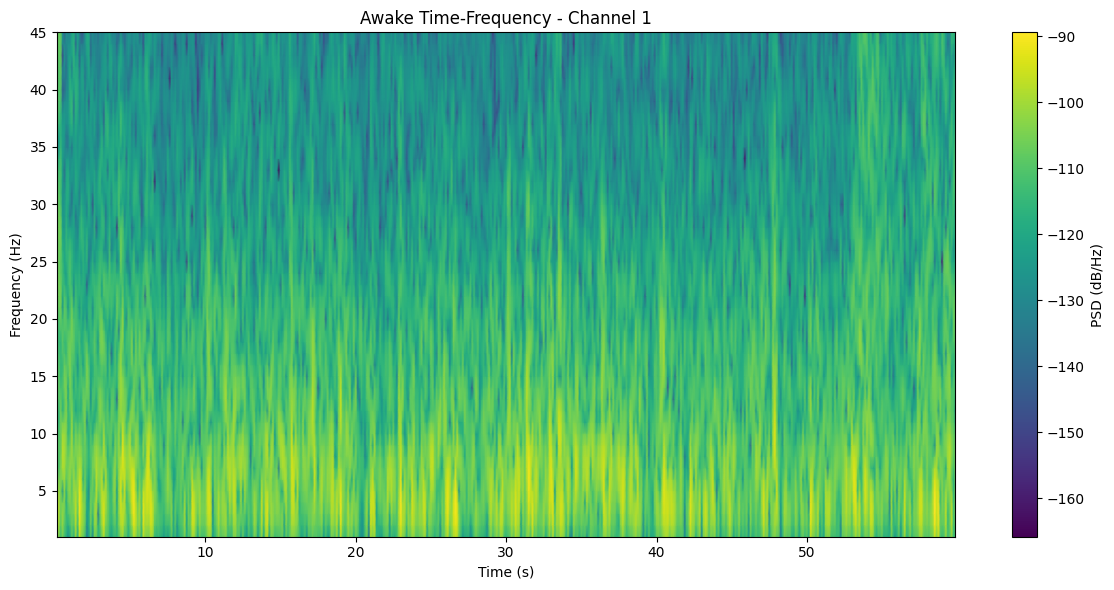

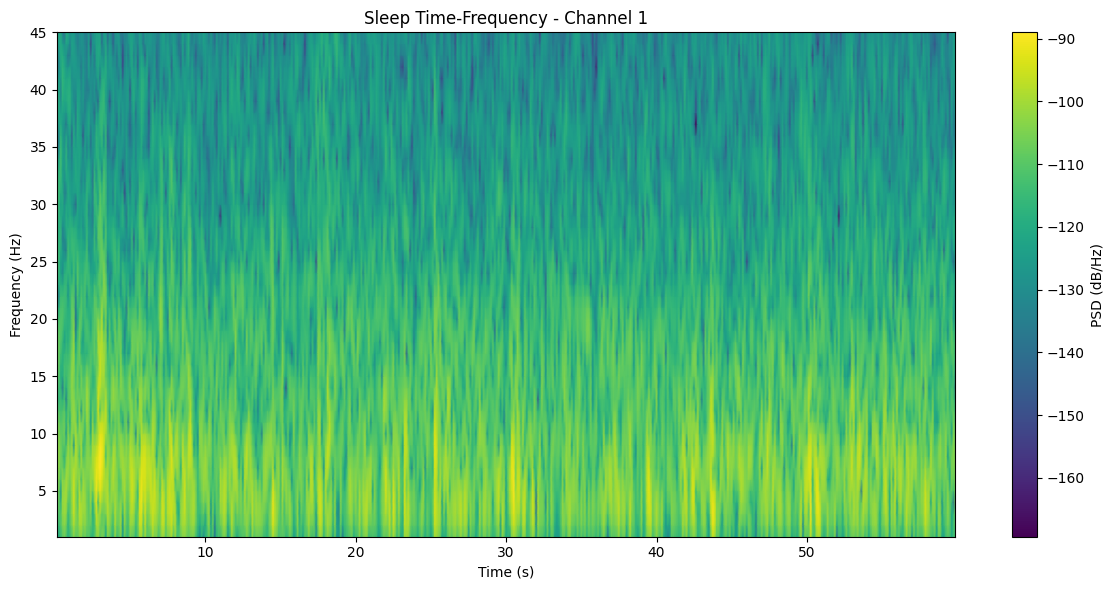

In [14]:
def analyze_time_frequency(raw, tmin=0, tmax=60, fmin=1, fmax=45):
    """Perform time-frequency analysis to see dynamic changes"""
    # Extract data segment
    data, times = raw.get_data(return_times=True)
    
    # Select time range
    time_mask = (times >= tmin) & (times <= tmax)
    data = data[:, time_mask]
    times = times[time_mask]
    
    # Create epochs for TF analysis (1s epochs with 50% overlap)
    epoch_length = int(raw.info['sfreq'])
    step = epoch_length // 2
    
    epochs_data = []
    for i in range(0, data.shape[1] - epoch_length, step):
        epochs_data.append(data[:, i:i+epoch_length])
    
    epochs_data = np.array(epochs_data)  # shape: (n_epochs, n_channels, n_times)
    
    # Compute time-frequency representation
    from scipy import signal
    
    # For demonstration, analyze first channel only
    channel_idx = 0
    freqs, times, Sxx = signal.spectrogram(
        data[channel_idx], 
        fs=raw.info['sfreq'],
        nperseg=epoch_length//4,
        noverlap=epoch_length//8,
        nfft=epoch_length,
        mode='psd'
    )
    
    # Keep only frequencies in our range of interest
    freq_mask = (freqs >= fmin) & (freqs <= fmax)
    freqs = freqs[freq_mask]
    Sxx = Sxx[freq_mask]
    
    return freqs, times, Sxx, channel_idx

# Perform time-frequency analysis
freqs_awake, times_awake, tf_awake, ch_idx = analyze_time_frequency(awake_60hz_clean)
freqs_sleep, times_sleep, tf_sleep, _ = analyze_time_frequency(sleep_60hz_clean)

# Plot the results
def plot_tf(freqs, times, tf_data, title):
    plt.figure(figsize=(12, 6))
    plt.pcolormesh(times, freqs, 10 * np.log10(tf_data), cmap='viridis', shading='gouraud')
    plt.colorbar(label='PSD (dB/Hz)')
    plt.ylim(freqs[0], freqs[-1])
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'{title} - Channel {ch_idx+1}')
    plt.tight_layout()
    plt.show()

plot_tf(freqs_awake, times_awake, tf_awake, 'Awake Time-Frequency')
plot_tf(freqs_sleep, times_sleep, tf_sleep, 'Sleep Time-Frequency')

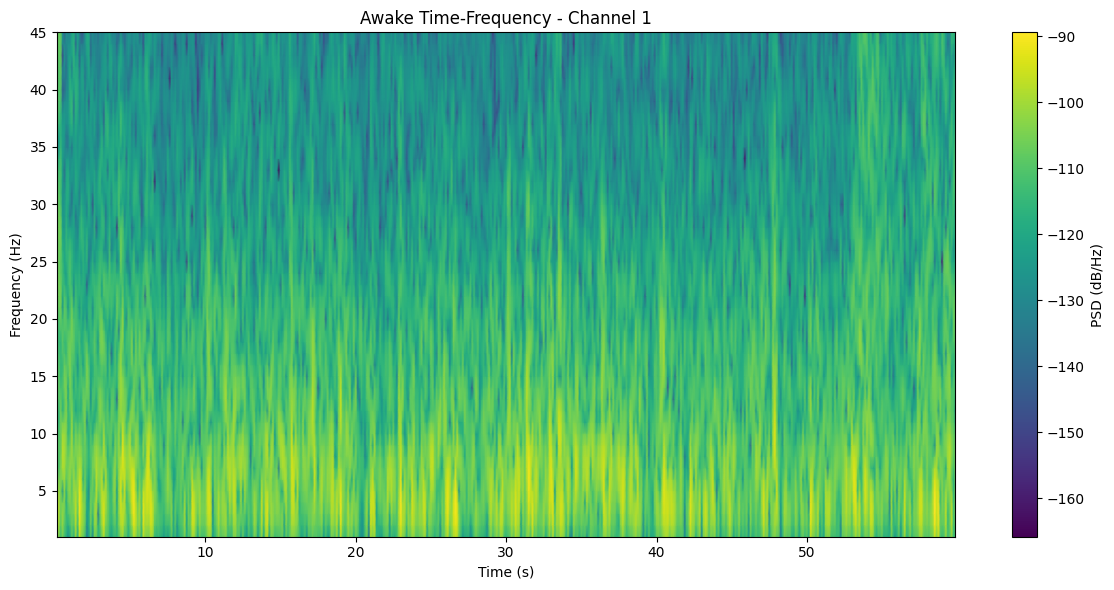

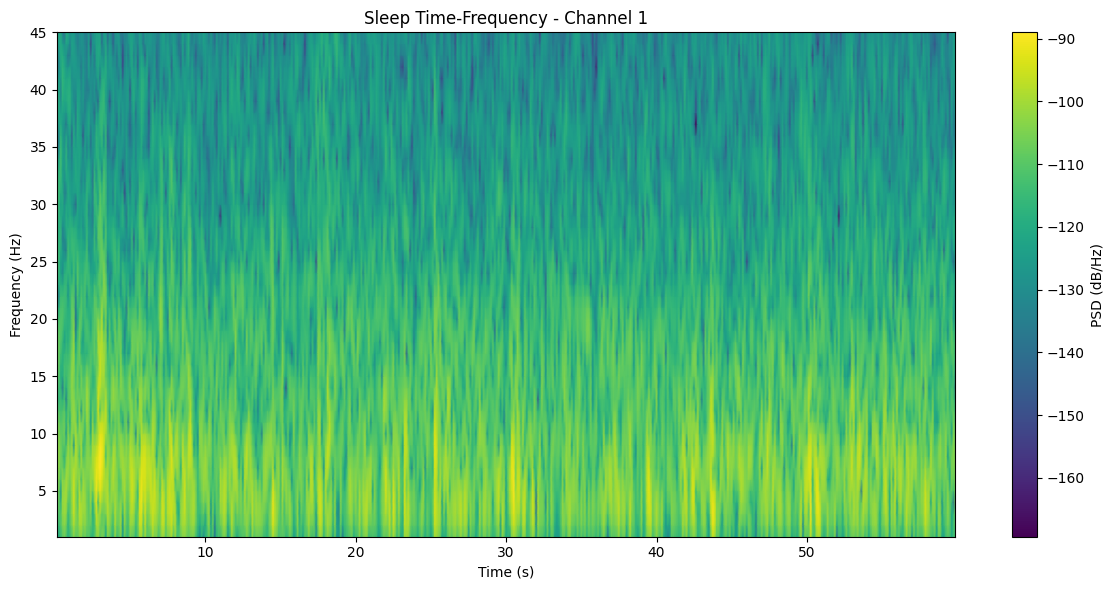

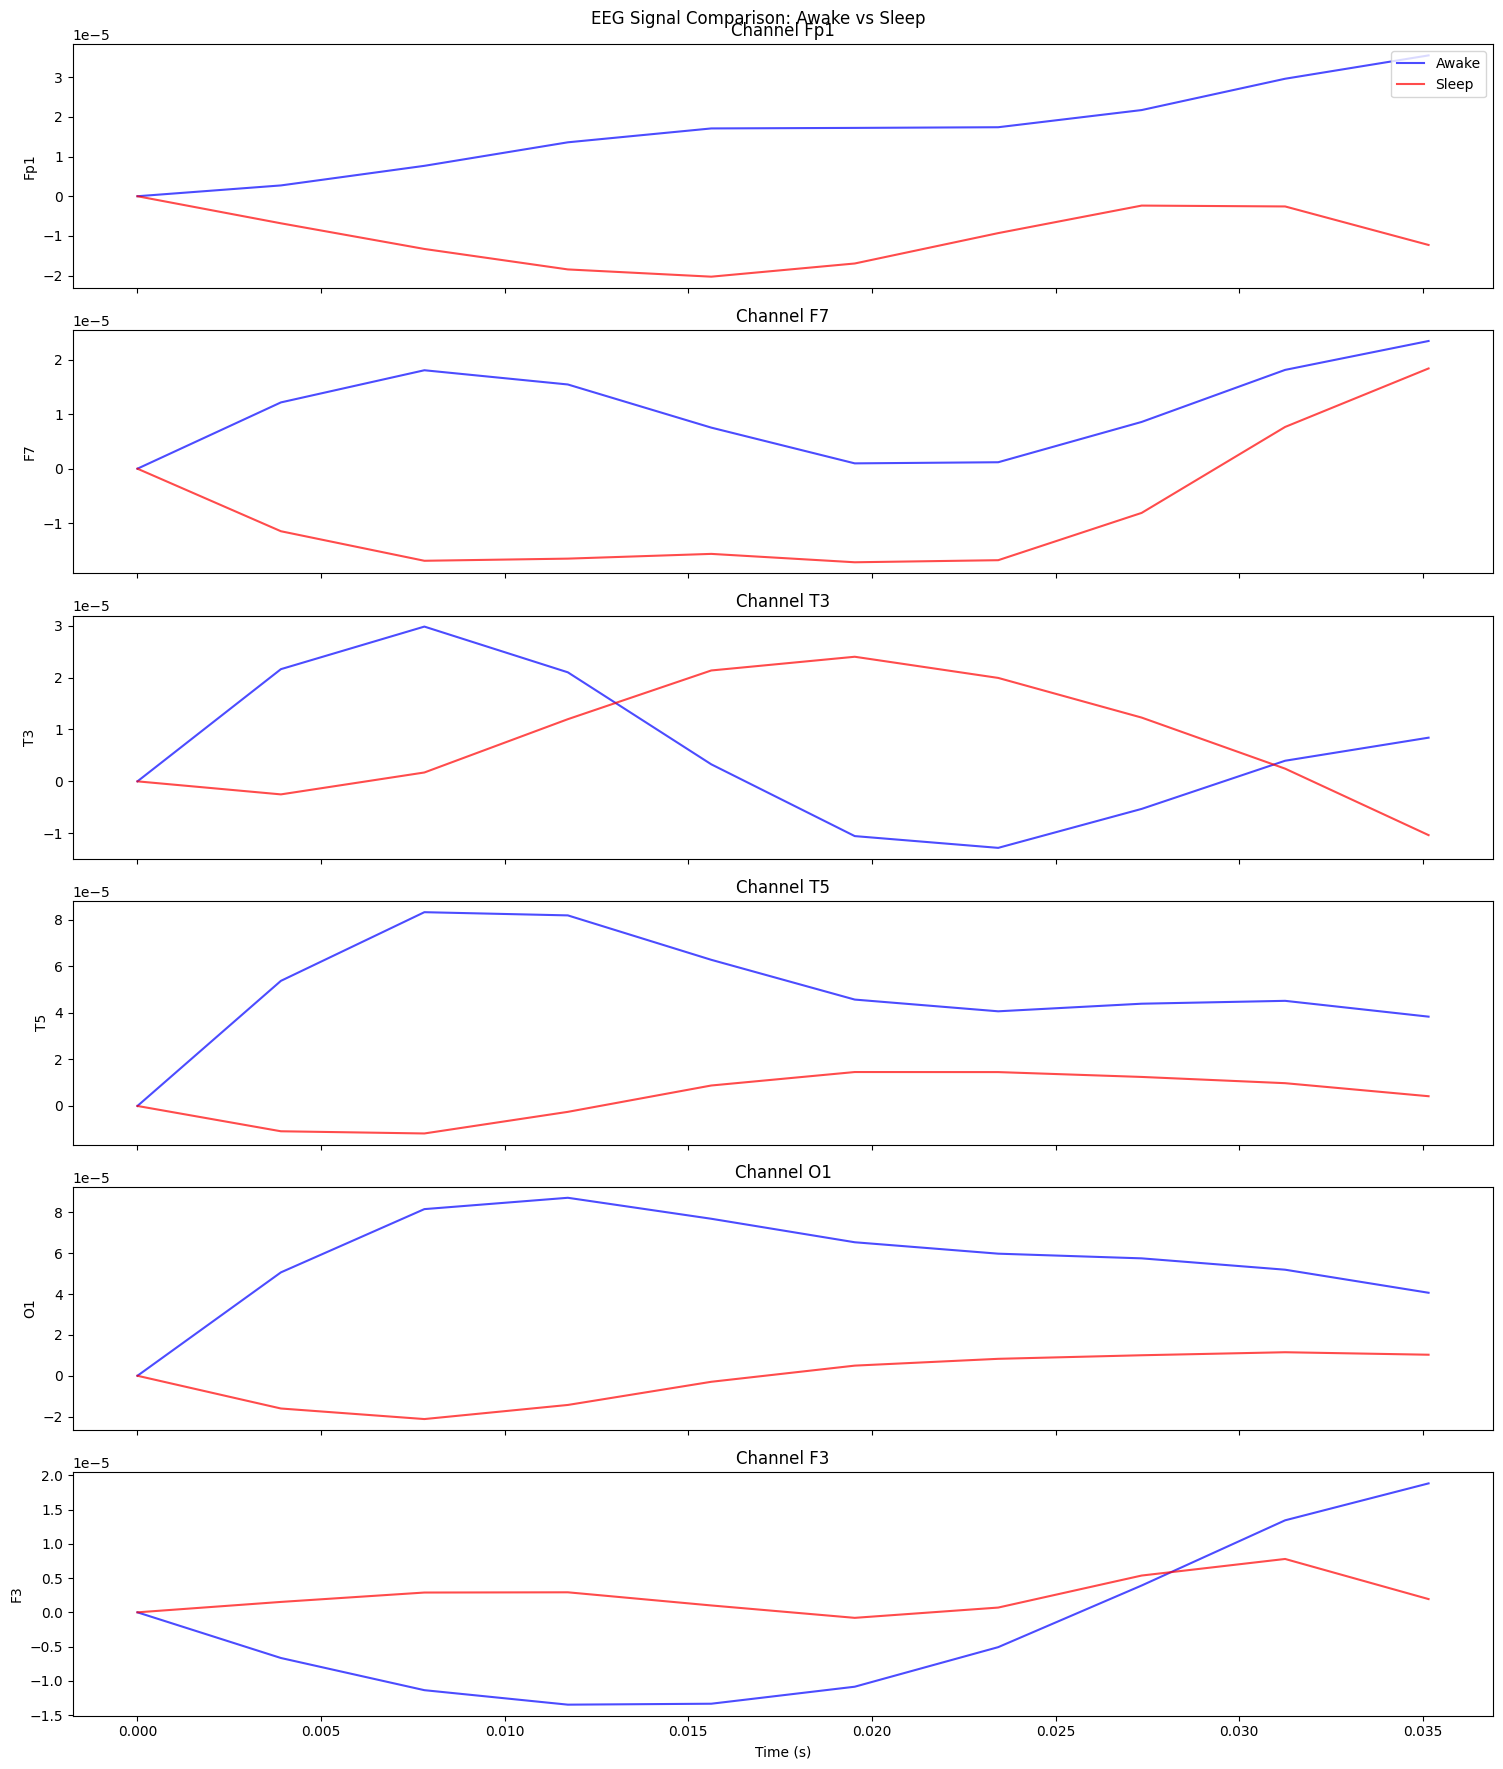

In [19]:
def plot_channel_comparison(raw_awake, raw_sleep, n_channels=None, duration=10, start=0):
    """Plot comparison of raw signals for awake and sleep states"""
    if n_channels is None:
        n_channels = min(len(raw_awake.ch_names), 48)  # Default to 48 channels or fewer
    
    # Get channel names for consistency in plotting
    channels = raw_awake.ch_names[:n_channels]
    
    fig, axes = plt.subplots(n_channels, 1, figsize=(15, 3*n_channels), sharex=True)
    
    # Plot awake data
    data_awake, times_awake = raw_awake.get_data(
        picks=channels, 
        start=start, 
        stop=start+duration,
        return_times=True
    )
    
    # Plot sleep data
    data_sleep, times_sleep = raw_sleep.get_data(
        picks=channels, 
        start=start, 
        stop=start+duration,
        return_times=True
    )
    
    for i, channel in enumerate(channels):
        axes[i].plot(times_awake, data_awake[i], 'b-', alpha=0.7, label='Awake')
        axes[i].plot(times_sleep, data_sleep[i], 'r-', alpha=0.7, label='Sleep')
        axes[i].set_ylabel(channel)
        axes[i].set_title(f"Channel {channel}")
        
        if i == 0:  # Only add legend to the first subplot
            axes[i].legend(loc='upper right')
    
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle('EEG Signal Comparison: Awake vs Sleep')
    plt.tight_layout()
    plt.show()

# Plot the first 10 seconds of data for the first 6 channels
plot_channel_comparison(awake_60hz_clean, sleep_60hz_clean, n_channels=6, duration=10)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)


Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/466565444.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)


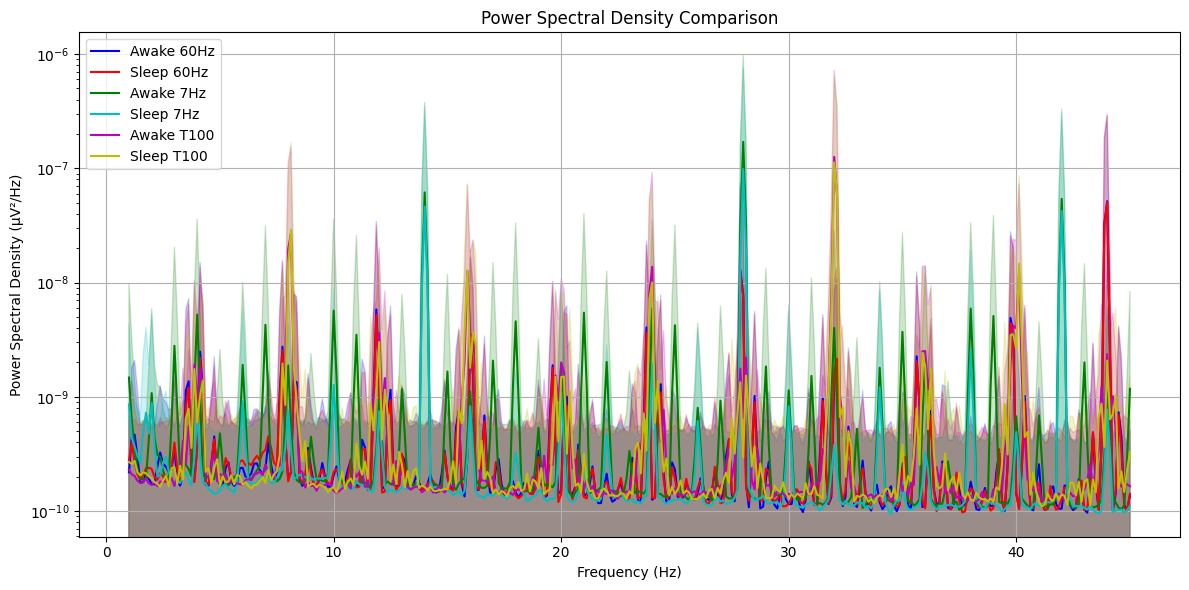

In [20]:
def plot_psd_comparison(raw_list, labels, fmin=1, fmax=45):
    """Plot PSD comparison for multiple raw objects"""
    plt.figure(figsize=(12, 6))
    
    colors = ['b', 'r', 'g', 'c', 'm', 'y']
    
    for i, (raw, label) in enumerate(zip(raw_list, labels)):
        psds, freqs = raw.compute_psd(fmin=fmin, fmax=fmax).get_data(return_freqs=True)
        
        # Average across channels
        mean_psd = psds.mean(axis=0)
        std_psd = psds.std(axis=0)
        
        plt.semilogy(freqs, mean_psd, colors[i % len(colors)], label=label)
        plt.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd, 
                         color=colors[i % len(colors)], alpha=0.2)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectral Density (µV²/Hz)')
    plt.title('Power Spectral Density Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Compare all XU datasets
raw_list = [awake_60hz_clean, sleep_60hz_clean, awake_7hz, sleep_7hz, awake_t100, sleep_t100]
labels = ['Awake 60Hz', 'Sleep 60Hz', 'Awake 7Hz', 'Sleep 7Hz', 'Awake T100', 'Sleep T100']
plot_psd_comparison(raw_list, labels)

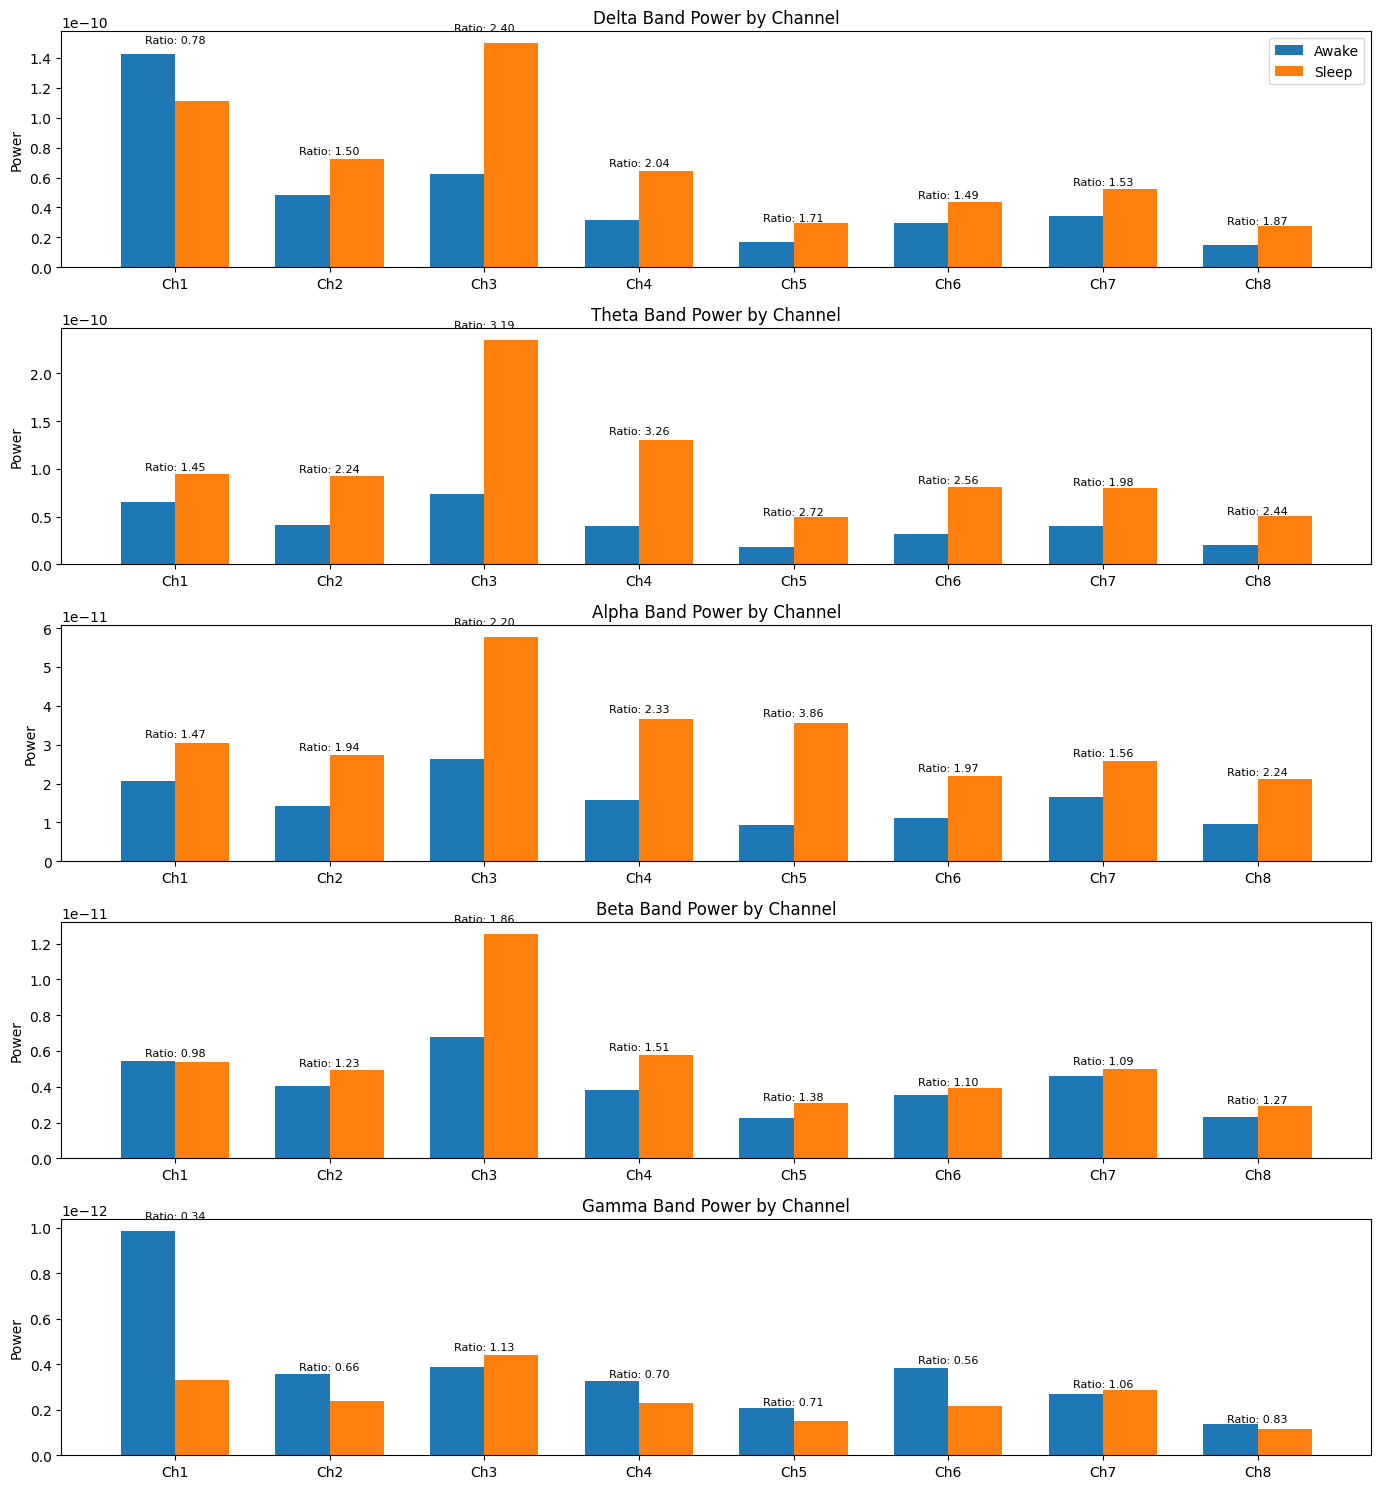

In [21]:
def plot_band_power_by_channel(powers_awake, powers_sleep, n_channels=8):
    """Plot band powers for each channel"""
    bands = list(powers_awake.keys())
    channels = min(len(powers_awake[bands[0]]), n_channels)
    
    fig, axes = plt.subplots(len(bands), 1, figsize=(14, 3*len(bands)))
    
    x = np.arange(channels)
    width = 0.35
    
    for i, band in enumerate(bands):
        power_awake = powers_awake[band][:channels]
        power_sleep = powers_sleep[band][:channels]
        
        axes[i].bar(x - width/2, power_awake, width, label='Awake')
        axes[i].bar(x + width/2, power_sleep, width, label='Sleep')
        
        axes[i].set_title(f'{band.capitalize()} Band Power by Channel')
        axes[i].set_ylabel('Power')
        axes[i].set_xticks(x)
        axes[i].set_xticklabels([f'Ch{j+1}' for j in range(channels)])
        
        # Add ratio text
        for j in range(channels):
            ratio = power_sleep[j] / power_awake[j] if power_awake[j] != 0 else float('inf')
            axes[i].text(j, max(power_awake[j], power_sleep[j]) * 1.05, 
                         f"Ratio: {ratio:.2f}", ha='center', fontsize=8)
        
        if i == 0:
            axes[i].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Plot band powers for first 8 channels
plot_band_power_by_channel(awake_60hz_powers, sleep_60hz_powers, n_channels=8)

/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/wanghley/Workspace/Projects/ML-driven EEG biomarkers/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


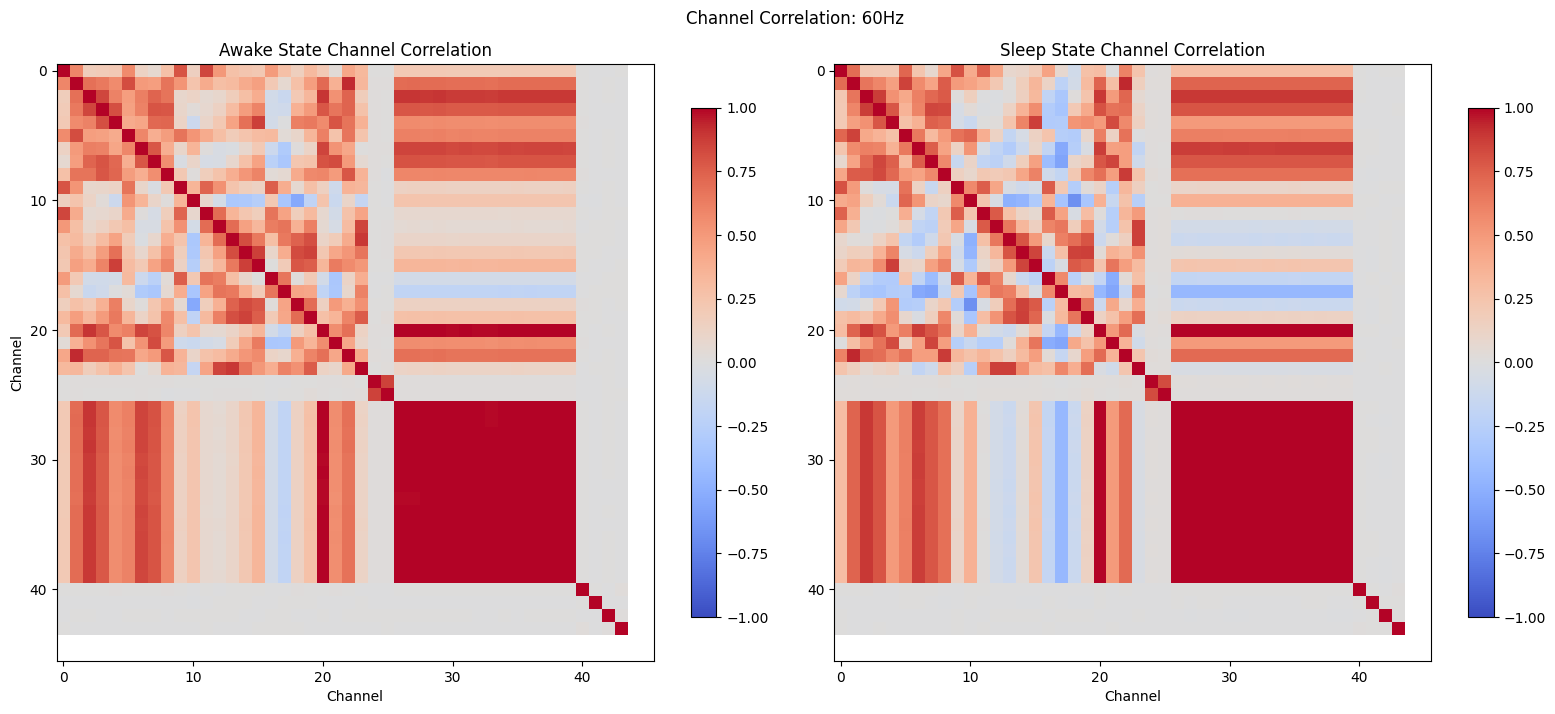

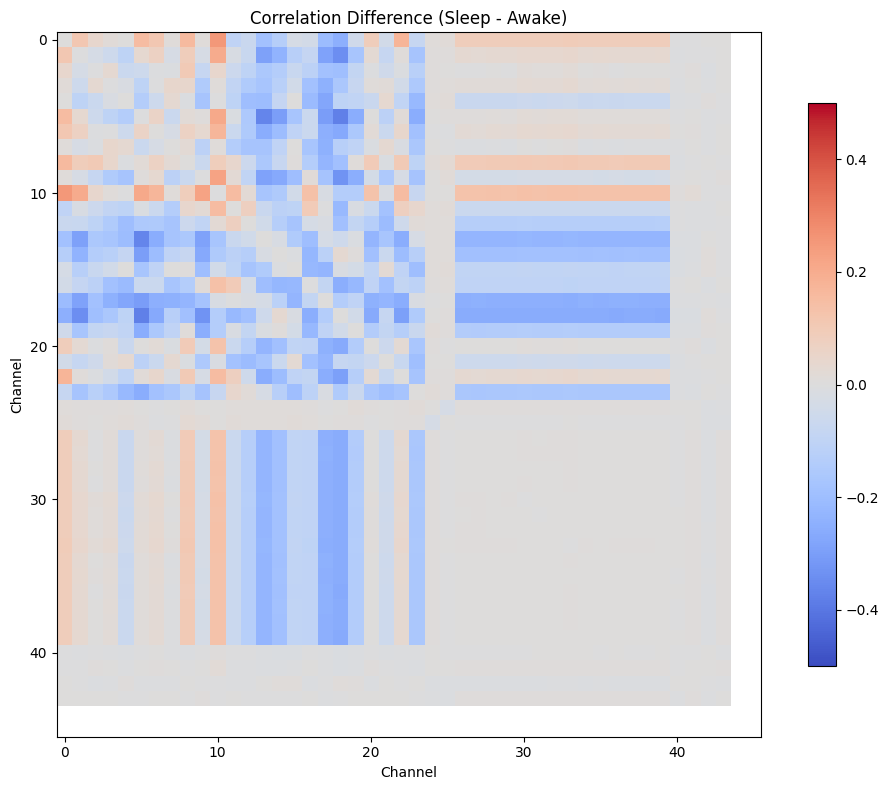

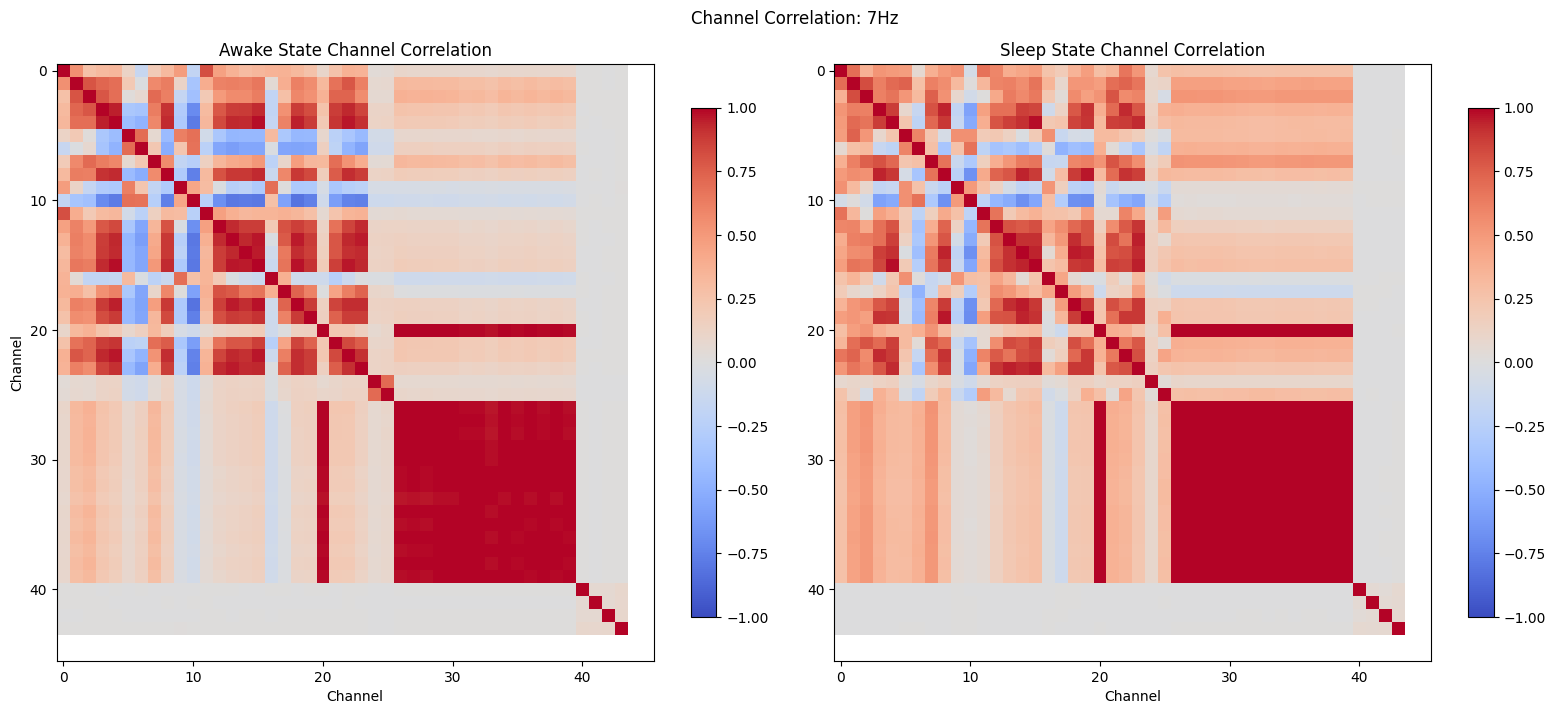

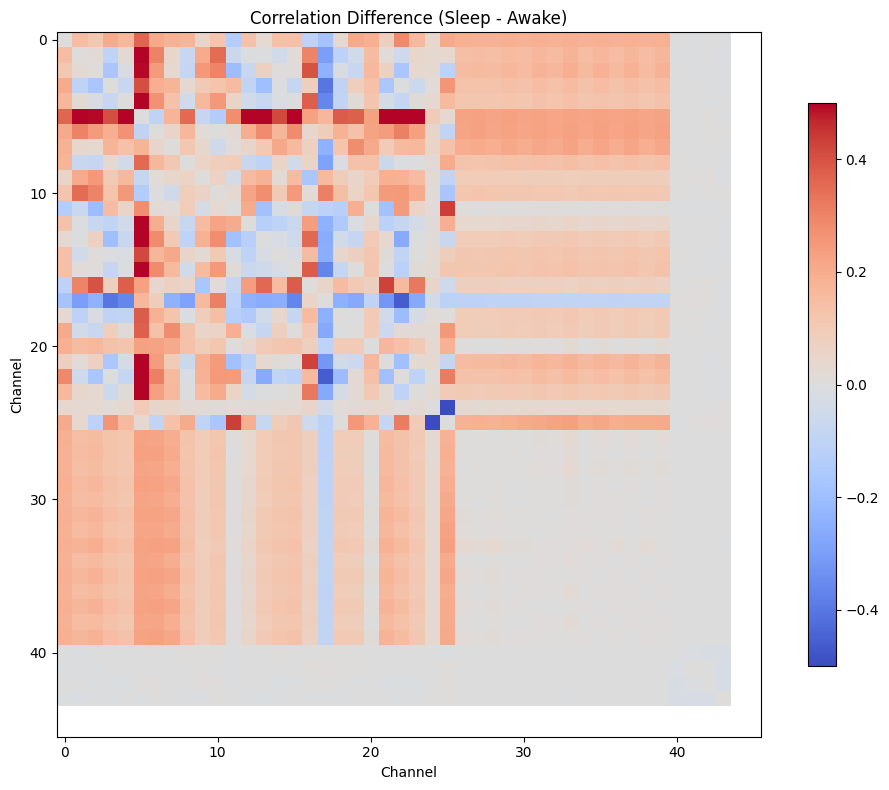

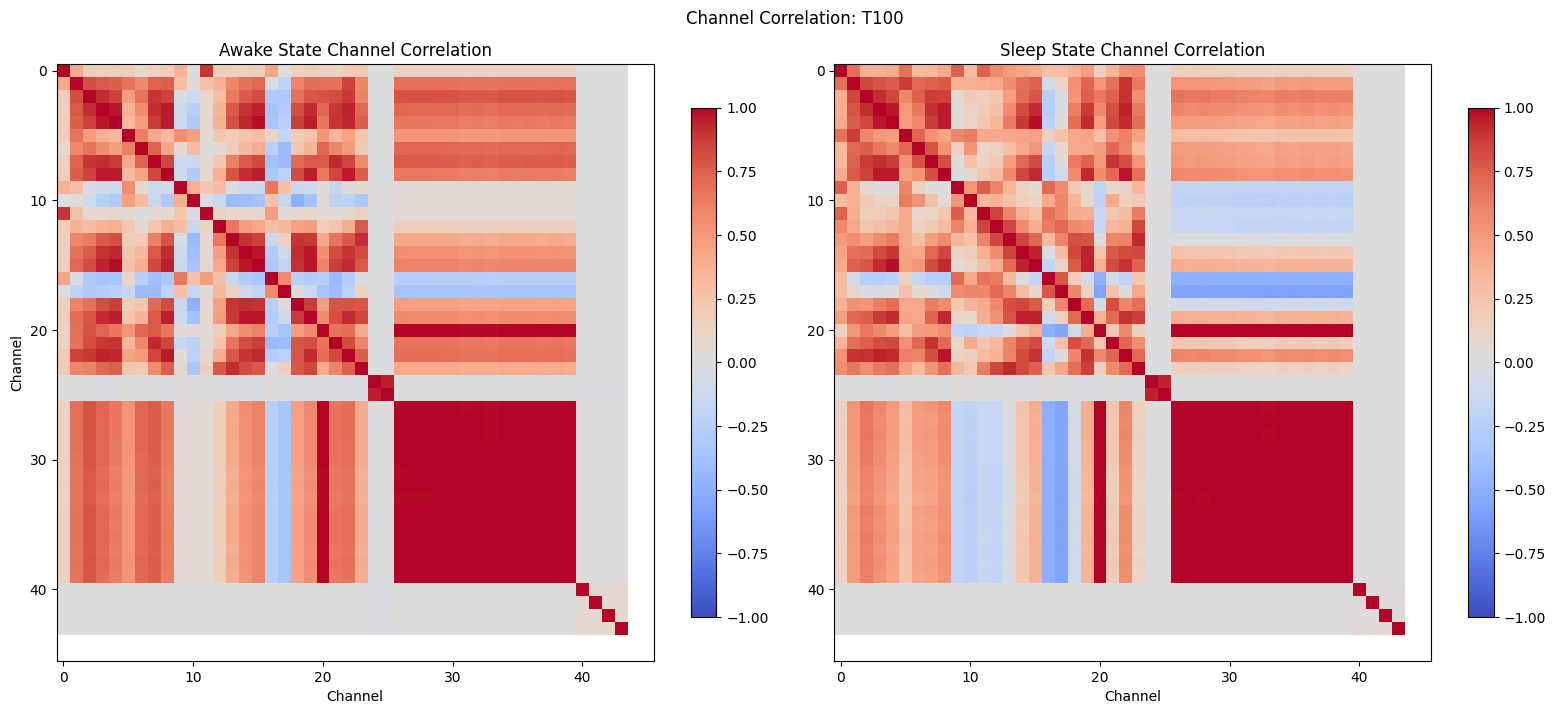

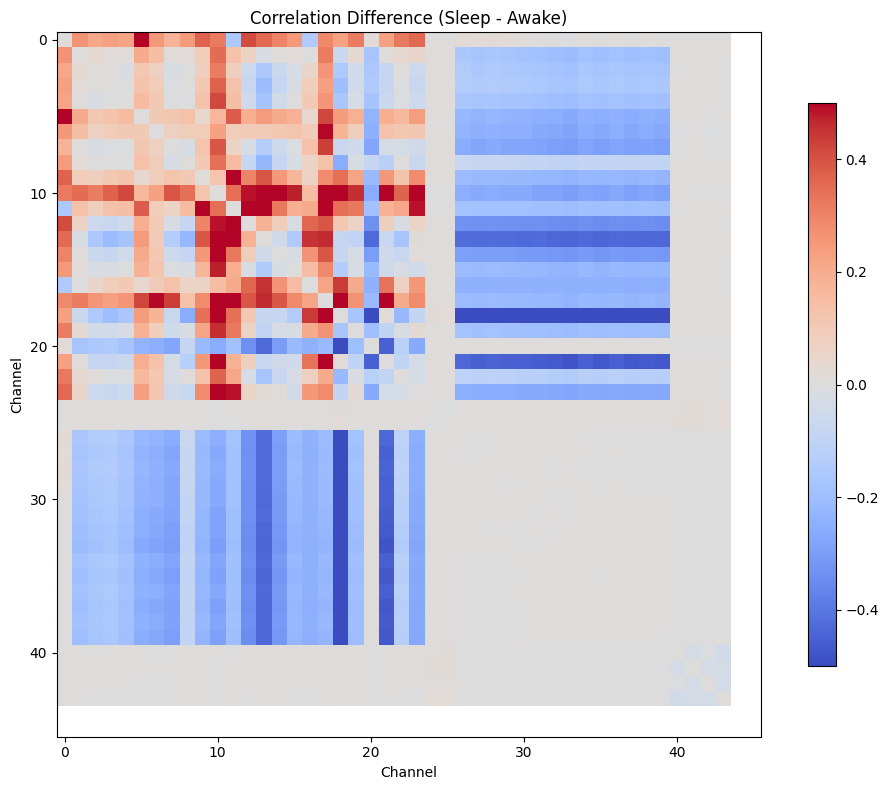

In [22]:
def plot_channel_correlation(raw_awake, raw_sleep, title="Channel Correlation Comparison"):
    """Plot correlation matrix between channels for awake and sleep"""
    data_awake = raw_awake.get_data()
    data_sleep = raw_sleep.get_data()
    
    corr_awake = np.corrcoef(data_awake)
    corr_sleep = np.corrcoef(data_sleep)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot awake correlation
    im0 = axes[0].imshow(corr_awake, cmap='coolwarm', vmin=-1, vmax=1)
    axes[0].set_title('Awake State Channel Correlation')
    axes[0].set_xlabel('Channel')
    axes[0].set_ylabel('Channel')
    
    # Plot sleep correlation
    im1 = axes[1].imshow(corr_sleep, cmap='coolwarm', vmin=-1, vmax=1)
    axes[1].set_title('Sleep State Channel Correlation')
    axes[1].set_xlabel('Channel')
    
    # Add colorbars
    fig.colorbar(im0, ax=axes[0], shrink=0.8)
    fig.colorbar(im1, ax=axes[1], shrink=0.8)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
    # Calculate difference in correlation
    corr_diff = corr_sleep - corr_awake
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(corr_diff, cmap='coolwarm', vmin=-0.5, vmax=0.5)
    plt.colorbar(im, shrink=0.8)
    plt.title('Correlation Difference (Sleep - Awake)')
    plt.xlabel('Channel')
    plt.ylabel('Channel')
    plt.tight_layout()
    plt.show()

# Plot correlation matrices for 60Hz data
plot_channel_correlation(awake_60hz_clean, sleep_60hz_clean, "Channel Correlation: 60Hz")

# Plot correlation matrices for 7Hz data
plot_channel_correlation(awake_7hz, sleep_7hz, "Channel Correlation: 7Hz")

# Plot correlation matrices for T100 data
plot_channel_correlation(awake_t100, sleep_t100, "Channel Correlation: T100")

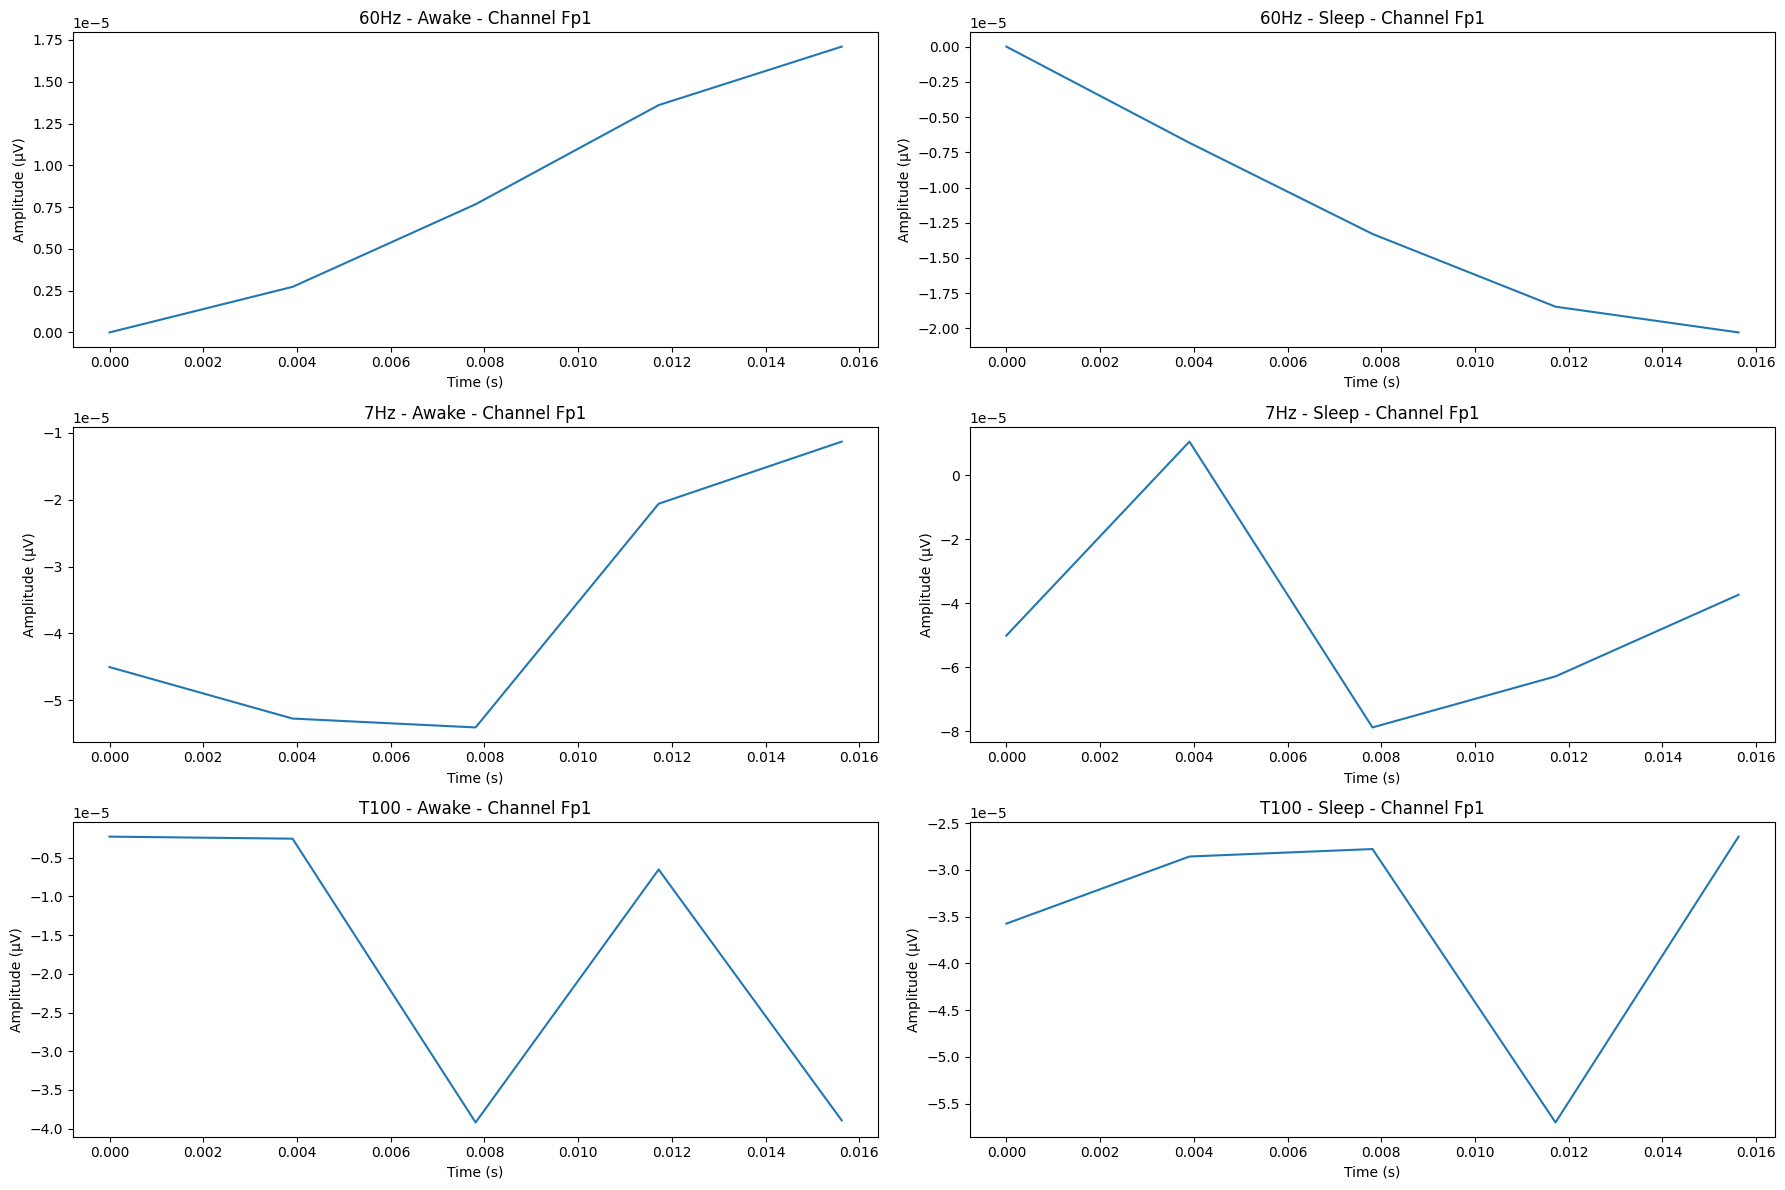

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:45: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_awake = raw_awake.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:46: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_sleep = raw_sleep.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:45: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_awake = raw_awake.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:46: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_sleep = raw_sleep.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:45: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_awake = raw_awake.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1424549900.py:46: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd_sleep = raw_sleep.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


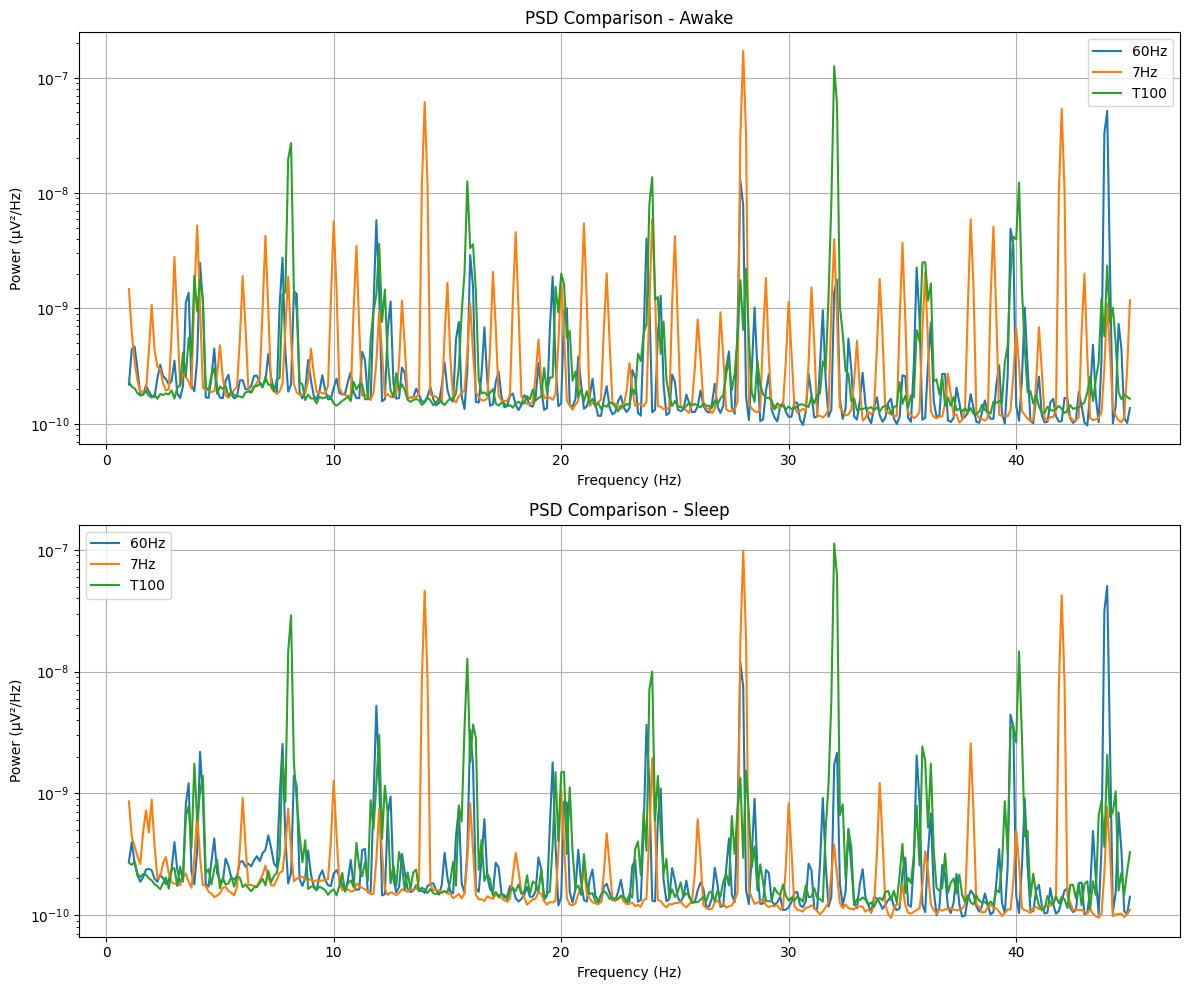

In [23]:
def compare_stimulation_settings(raw_awake_list, raw_sleep_list, labels, duration=5):
    """Compare different stimulation settings"""
    n_settings = len(raw_awake_list)
    
    # Choose a representative channel
    ch_idx = 0  # first channel
    
    fig, axes = plt.subplots(n_settings, 2, figsize=(18, 4*n_settings))
    
    for i, (raw_awake, raw_sleep, label) in enumerate(zip(raw_awake_list, raw_sleep_list, labels)):
        # Get channel name
        ch_name = raw_awake.ch_names[ch_idx]
        
        # Get data for awake state
        data_awake, times_awake = raw_awake.get_data(picks=[ch_idx], 
                                                    start=0, 
                                                    stop=duration, 
                                                    return_times=True)
        
        # Get data for sleep state
        data_sleep, times_sleep = raw_sleep.get_data(picks=[ch_idx], 
                                                    start=0, 
                                                    stop=duration, 
                                                    return_times=True)
        
        # Plot time series
        axes[i, 0].plot(times_awake, data_awake[0])
        axes[i, 0].set_title(f"{label} - Awake - Channel {ch_name}")
        axes[i, 0].set_xlabel('Time (s)')
        axes[i, 0].set_ylabel('Amplitude (μV)')
        
        axes[i, 1].plot(times_sleep, data_sleep[0])
        axes[i, 1].set_title(f"{label} - Sleep - Channel {ch_name}")
        axes[i, 1].set_xlabel('Time (s)')
        axes[i, 1].set_ylabel('Amplitude (μV)')
    
    plt.tight_layout()
    plt.show()

    # Calculate and plot PSD for different settings
    fig, axes = plt.subplots(2, 1, figsize=(12, 10))
    
    for i, (raw_awake, raw_sleep, label) in enumerate(zip(raw_awake_list, raw_sleep_list, labels)):
        # Calculate PSD
        psd_awake = raw_awake.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
        psd_sleep = raw_sleep.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
        
        # Plot
        axes[0].semilogy(psd_awake[1], psd_awake[0].mean(axis=0), label=label)
        axes[1].semilogy(psd_sleep[1], psd_sleep[0].mean(axis=0), label=label)
    
    axes[0].set_title('PSD Comparison - Awake')
    axes[0].set_xlabel('Frequency (Hz)')
    axes[0].set_ylabel('Power (µV²/Hz)')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_title('PSD Comparison - Sleep')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Power (µV²/Hz)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Compare different stimulation settings
raw_awake_list = [awake_60hz_clean, awake_7hz, awake_t100]
raw_sleep_list = [sleep_60hz_clean, sleep_7hz, sleep_t100]
labels = ['60Hz', '7Hz', 'T100']

compare_stimulation_settings(raw_awake_list, raw_sleep_list, labels)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 20.00 Hz
- Upper transition bandwidth: 5.00 Hz (-6 dB cutoff frequency: 22.50 Hz)
- Filter length: 423 samples (1.652 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 20 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 20

ValueError: zero-size array to reduction operation minimum which has no identity

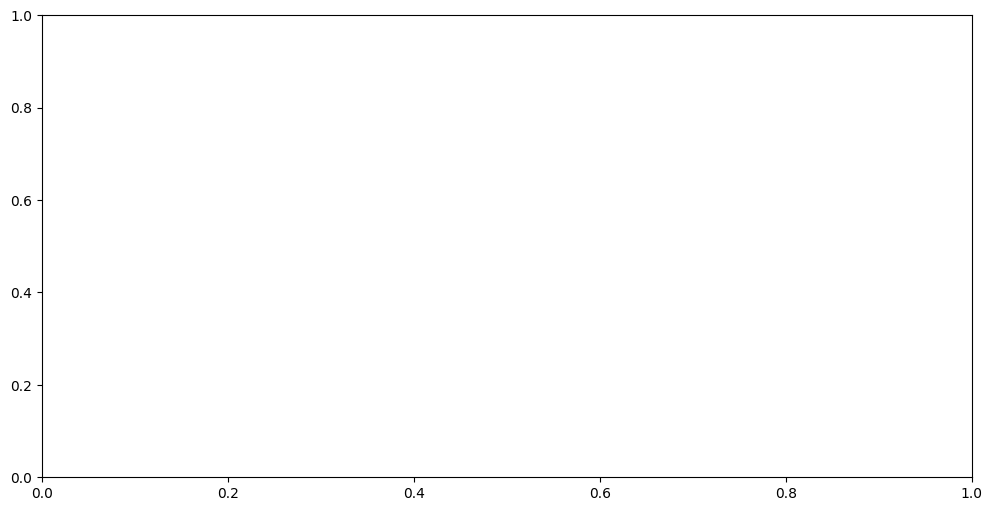

In [24]:
def analyze_seizure_features(seizures_list, labels):
    """Analyze and visualize seizure features"""
    if not any(seizures_list):
        print("No seizure events detected in any dataset")
        return
    
    # Extract durations for each dataset
    durations_list = []
    for seizures in seizures_list:
        if seizures:
            durations = [event['duration'] for event in seizures]
            durations_list.append(durations)
        else:
            durations_list.append([])
    
    # Plot duration distributions
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.violinplot(durations_list, showmeans=True)
    ax.set_xticks(range(1, len(labels)+1))
    ax.set_xticklabels(labels)
    ax.set_ylabel('Duration (s)')
    ax.set_title('Distribution of Detected Seizure Event Durations')
    
    # Add count annotations
    for i, durations in enumerate(durations_list):
        ax.text(i+1, 0.1, f"n={len(durations)}", ha='center')
    
    plt.tight_layout()
    plt.show()
    
    # Plot event count by channel
    channel_counts = []
    for seizures in seizures_list:
        if not seizures:
            channel_counts.append({})
            continue
            
        counts = {}
        for event in seizures:
            ch = event['channel']
            counts[ch] = counts.get(ch, 0) + 1
        channel_counts.append(counts)
    
    # Find all unique channels
    all_channels = set()
    for counts in channel_counts:
        all_channels.update(counts.keys())
    
    if all_channels:
        all_channels = sorted(list(all_channels))
        
        fig, ax = plt.subplots(figsize=(14, 6))
        
        x = np.arange(len(all_channels))
        width = 0.8 / len(labels)
        
        for i, (counts, label) in enumerate(zip(channel_counts, labels)):
            values = [counts.get(ch, 0) for ch in all_channels]
            ax.bar(x + i*width - 0.4, values, width, label=label)
        
        ax.set_xticks(x)
        ax.set_xticklabels([f'Ch{ch}' for ch in all_channels])
        ax.set_ylabel('Number of Events')
        ax.set_title('Seizure Events by Channel')
        ax.legend()
        
        plt.tight_layout()
        plt.show()

# Compare seizure features across datasets
awake_seizures_60hz = detect_seizure_activity(awake_60hz_clean)
sleep_seizures_60hz = detect_seizure_activity(sleep_60hz_clean)
awake_seizures_7hz = detect_seizure_activity(awake_7hz)
sleep_seizures_7hz = detect_seizure_activity(sleep_7hz)
awake_seizures_t100 = detect_seizure_activity(awake_t100)
sleep_seizures_t100 = detect_seizure_activity(sleep_t100)

seizures_list = [
    awake_seizures_60hz, sleep_seizures_60hz,
    awake_seizures_7hz, sleep_seizures_7hz,
    awake_seizures_t100, sleep_seizures_t100
]
labels = [
    'Awake 60Hz', 'Sleep 60Hz',
    'Awake 7Hz', 'Sleep 7Hz',
    'Awake T100', 'Sleep T100'
]

analyze_seizure_features(seizures_list, labels)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/640717287.py:28: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


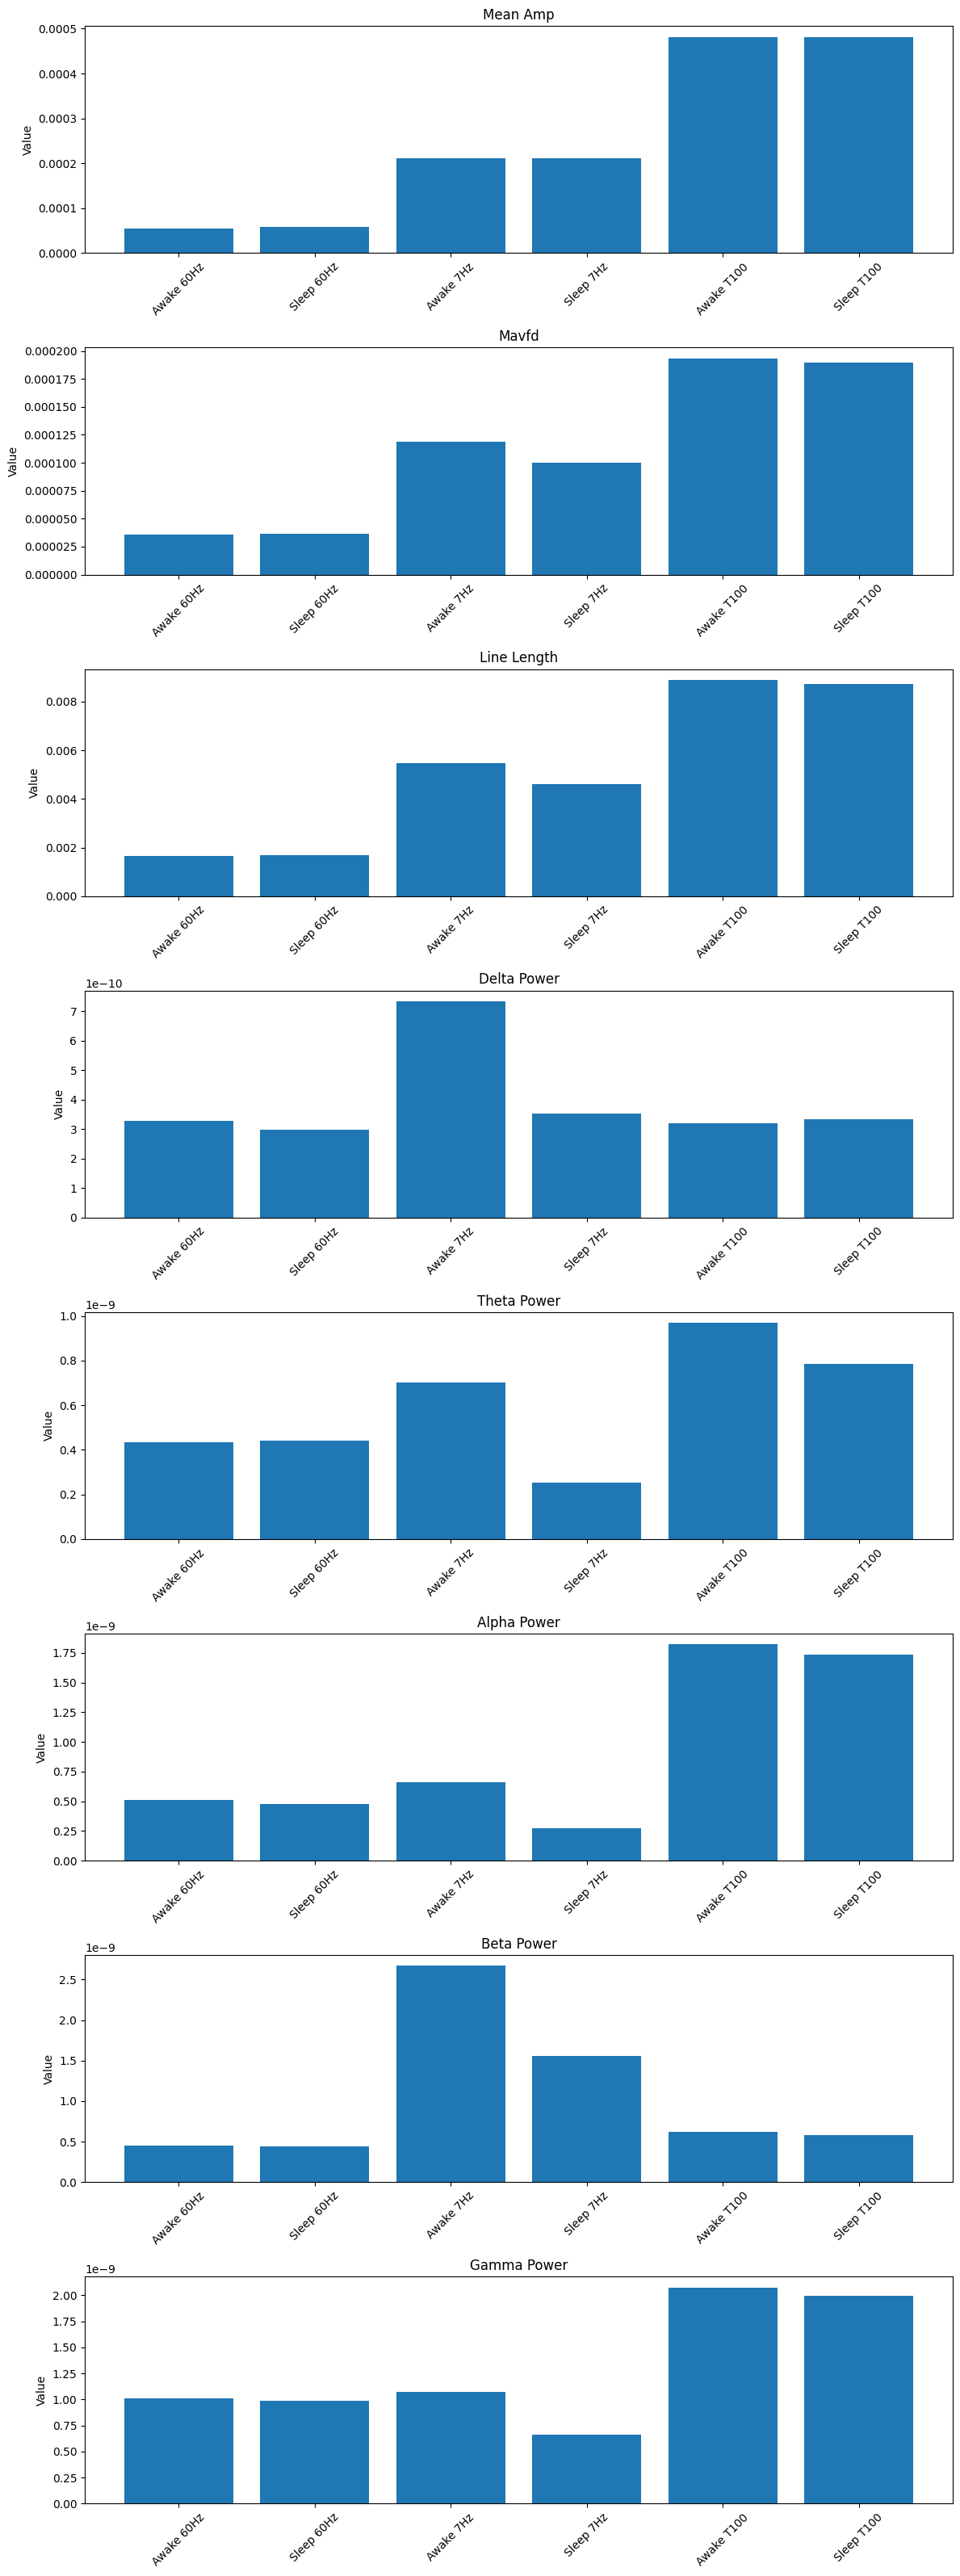

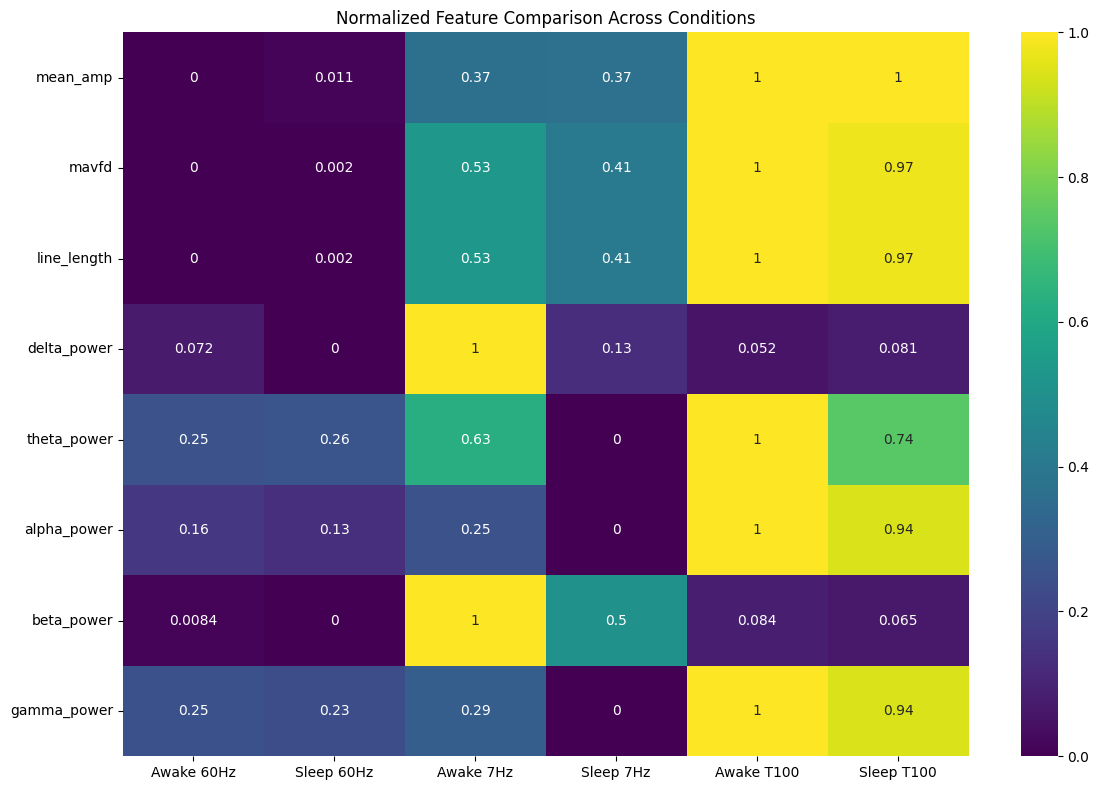

In [25]:
def statistical_comparison(raw_list, labels):
    """Perform statistical comparison across different conditions"""
    # Calculate features for each dataset
    features = {}
    
    for raw, label in zip(raw_list, labels):
        # Mean amplitude
        data = raw.get_data()
        mean_amp = np.mean(np.abs(data))
        
        # Mean absolute value of first derivative (MAVFD) - measure of signal variability
        diff = np.diff(data, axis=1)
        mavfd = np.mean(np.abs(diff))
        
        # Line length - another measure of signal complexity
        line_length = np.sum(np.abs(diff)) / diff.shape[1]
        
        # Calculate band powers
        bands = {
            'delta': (1, 4),
            'theta': (4, 8),
            'alpha': (8, 12),
            'beta': (12, 30),
            'gamma': (30, 45)
        }
        
        # Get PSDs
        psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
        
        # Calculate band powers
        band_powers = {}
        for band, (fmin, fmax) in bands.items():
            idx = (freqs >= fmin) & (freqs <= fmax)
            band_powers[band] = np.mean(psds[:, idx])
        
        # Store features
        features[label] = {
            'mean_amp': mean_amp,
            'mavfd': mavfd,
            'line_length': np.mean(line_length),
            **{f"{band}_power": power for band, power in band_powers.items()}
        }
    
    # Plot features comparison
    feature_names = list(features[labels[0]].keys())
    
    fig, axes = plt.subplots(len(feature_names), 1, figsize=(12, 4*len(feature_names)))
    
    for i, feature in enumerate(feature_names):
        values = [features[label][feature] for label in labels]
        
        axes[i].bar(labels, values)
        axes[i].set_title(f'{feature.replace("_", " ").title()}')
        axes[i].set_ylabel('Value')
        axes[i].tick_params(axis='x', rotation=45)
        
    plt.tight_layout()
    plt.show()
    
    # Create heatmap for normalized features
    normalized_features = {}
    for feature in feature_names:
        values = [features[label][feature] for label in labels]
        min_val, max_val = min(values), max(values)
        range_val = max_val - min_val if max_val > min_val else 1
        
        normalized_features[feature] = [(v - min_val) / range_val for v in values]
    
    # Convert to matrix
    heatmap_data = np.array([normalized_features[feature] for feature in feature_names])
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', 
                xticklabels=labels, yticklabels=feature_names)
    plt.title('Normalized Feature Comparison Across Conditions')
    plt.tight_layout()
    plt.show()

# Compare all conditions
raw_list = [awake_60hz_clean, sleep_60hz_clean, awake_7hz, sleep_7hz, awake_t100, sleep_t100]
labels = ['Awake 60Hz', 'Sleep 60Hz', 'Awake 7Hz', 'Sleep 7Hz', 'Awake T100', 'Sleep T100']

statistical_comparison(raw_list, labels)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/1811180655.py:8: UserWarning: Zero value in spectrum for channels OSAT, PR
  psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)


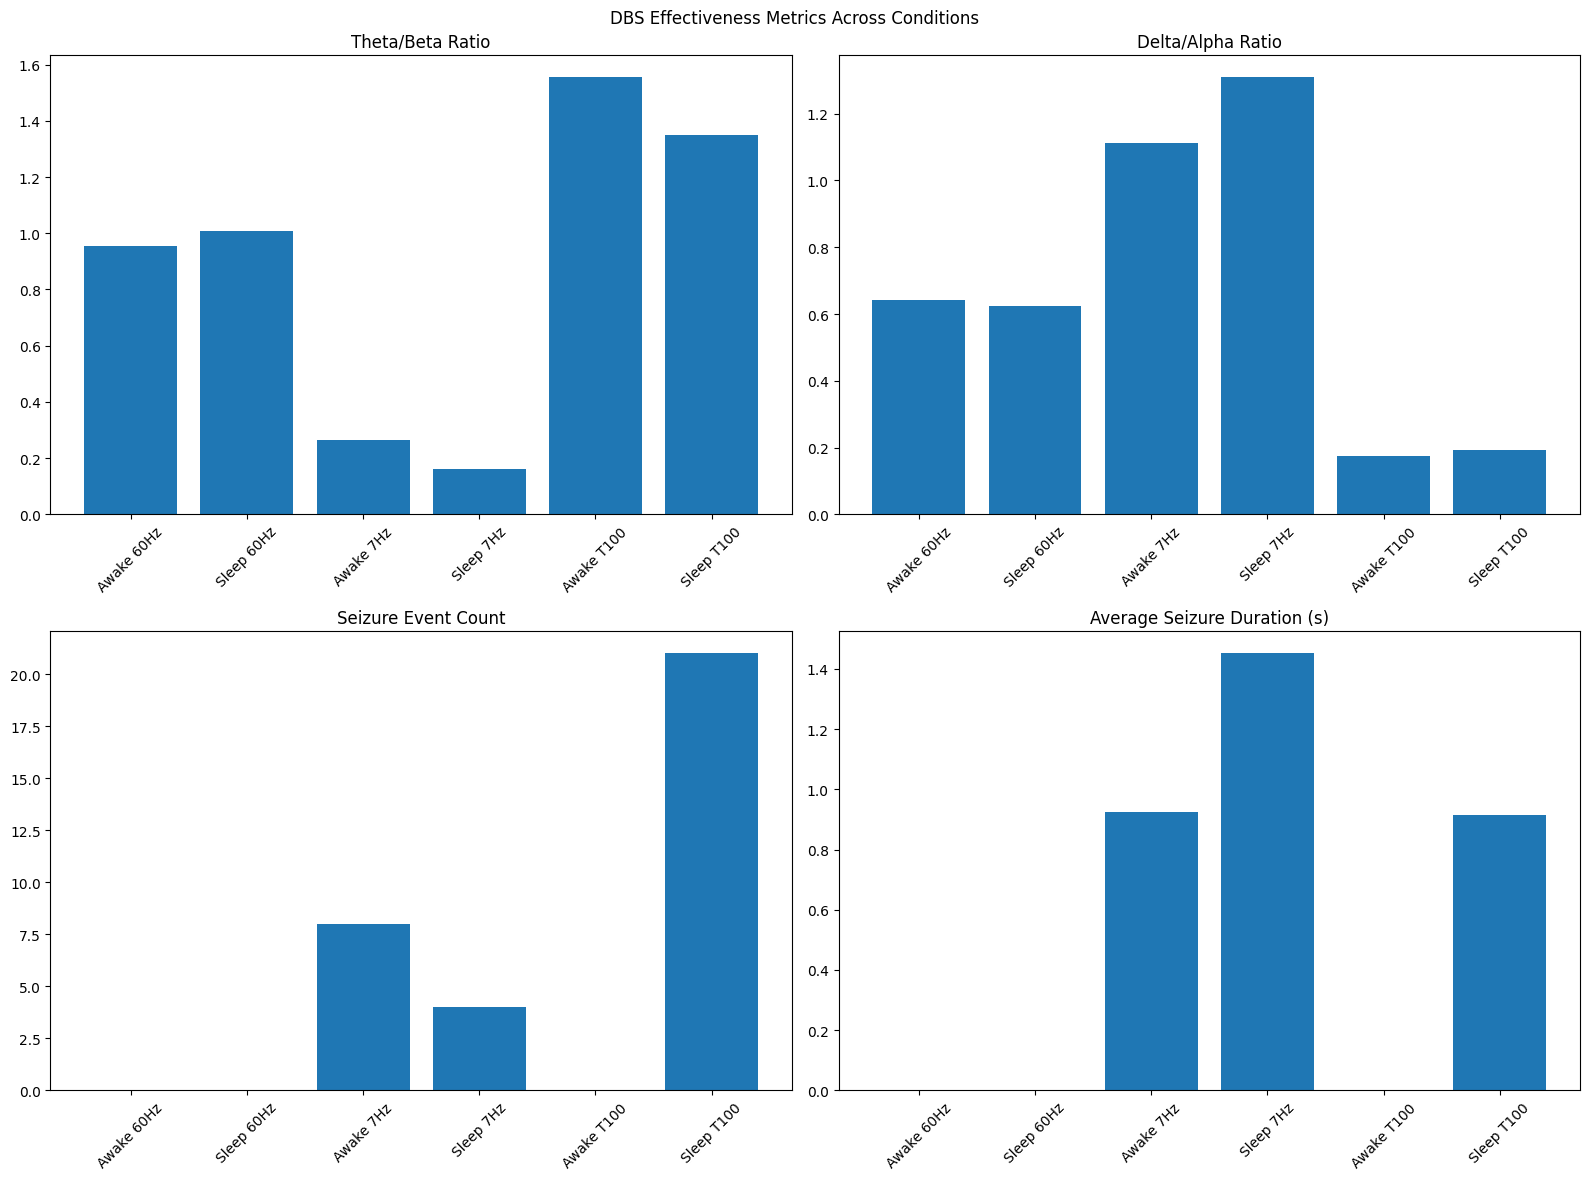

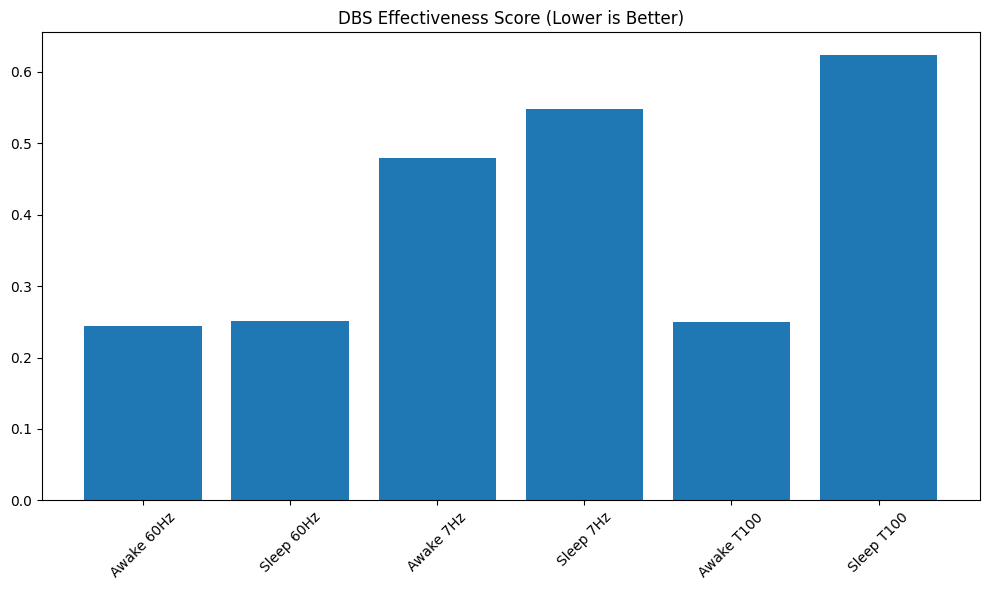

In [26]:
def assess_dbs_effectiveness(raw_list, seizure_list, labels):
    """Assess DBS effectiveness across different stimulation settings"""
    # Calculate key metrics
    metrics = {}
    
    for raw, seizures, label in zip(raw_list, seizure_list, labels):
        # Calculate PSD and extract band powers
        psds, freqs = raw.compute_psd(fmin=1, fmax=45).get_data(return_freqs=True)
        
        # Define frequency bands
        bands = {
            'delta': (1, 4),
            'theta': (4, 8),
            'alpha': (8, 12),
            'beta': (12, 30),
            'gamma': (30, 45)
        }
        
        # Calculate band powers
        band_powers = {}
        for band, (fmin, fmax) in bands.items():
            idx = (freqs >= fmin) & (freqs <= fmax)
            band_powers[band] = np.mean(psds[:, idx])
        
        # Calculate ratios (commonly used for seizure detection)
        theta_beta = band_powers['theta'] / band_powers['beta'] if band_powers['beta'] > 0 else float('inf')
        delta_alpha = band_powers['delta'] / band_powers['alpha'] if band_powers['alpha'] > 0 else float('inf')
        
        # Seizure metrics
        seizure_count = len(seizures)
        avg_duration = np.mean([event['duration'] for event in seizures]) if seizures else 0
        
        # Store metrics
        metrics[label] = {
            'theta_beta': theta_beta,
            'delta_alpha': delta_alpha,
            'seizure_count': seizure_count,
            'avg_duration': avg_duration
        }
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot theta/beta ratio
    axes[0, 0].bar(labels, [metrics[label]['theta_beta'] for label in labels])
    axes[0, 0].set_title('Theta/Beta Ratio')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot delta/alpha ratio
    axes[0, 1].bar(labels, [metrics[label]['delta_alpha'] for label in labels])
    axes[0, 1].set_title('Delta/Alpha Ratio')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Plot seizure count
    axes[1, 0].bar(labels, [metrics[label]['seizure_count'] for label in labels])
    axes[1, 0].set_title('Seizure Event Count')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    # Plot average seizure duration
    axes[1, 1].bar(labels, [metrics[label]['avg_duration'] for label in labels])
    axes[1, 1].set_title('Average Seizure Duration (s)')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.suptitle('DBS Effectiveness Metrics Across Conditions')
    plt.tight_layout()
    plt.show()
    
    # Create effectiveness score (lower is better)
    # Combining normalized metrics with weights
    scores = {}
    
    # Normalize each metric
    metrics_to_normalize = ['theta_beta', 'delta_alpha', 'seizure_count', 'avg_duration']
    normalized = {}
    
    for metric in metrics_to_normalize:
        values = [metrics[label][metric] for label in labels]
        min_val, max_val = min(values), max(values)
        range_val = max_val - min_val if max_val > min_val else 1
        
        normalized[metric] = [(v - min_val) / range_val if range_val > 0 else 0 for v in values]
    
    # Calculate weighted score (all metrics weighted equally for now)
    weights = {
        'theta_beta': 0.25,
        'delta_alpha': 0.25,
        'seizure_count': 0.25,
        'avg_duration': 0.25
    }
    
    for i, label in enumerate(labels):
        scores[label] = sum(weights[metric] * normalized[metric][i] for metric in metrics_to_normalize)
    
    # Plot effectiveness score (lower is better)
    plt.figure(figsize=(10, 6))
    plt.bar(labels, [scores[label] for label in labels])
    plt.title('DBS Effectiveness Score (Lower is Better)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Assess DBS effectiveness
raw_list = [awake_60hz_clean, sleep_60hz_clean, awake_7hz, sleep_7hz, awake_t100, sleep_t100]
seizure_list = [
    awake_seizures_60hz, sleep_seizures_60hz,
    awake_seizures_7hz, sleep_seizures_7hz,
    awake_seizures_t100, sleep_seizures_t100
]
labels = ['Awake 60Hz', 'Sleep 60Hz', 'Awake 7Hz', 'Sleep 7Hz', 'Awake T100', 'Sleep T100']

assess_dbs_effectiveness(raw_list, seizure_list, labels)

Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)


Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)


Effective window size : 8.000 (s)
Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)


Effective window size : 8.000 (s)


/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)
/var/folders/r5/m5977dy13hd_9klxgsmylm740000gn/T/ipykernel_59262/2715273613.py:17: UserWarning: Zero value in spectrum for channels OSAT, PR
  psd = raw.compute_psd(fmin=45, fmax=65)


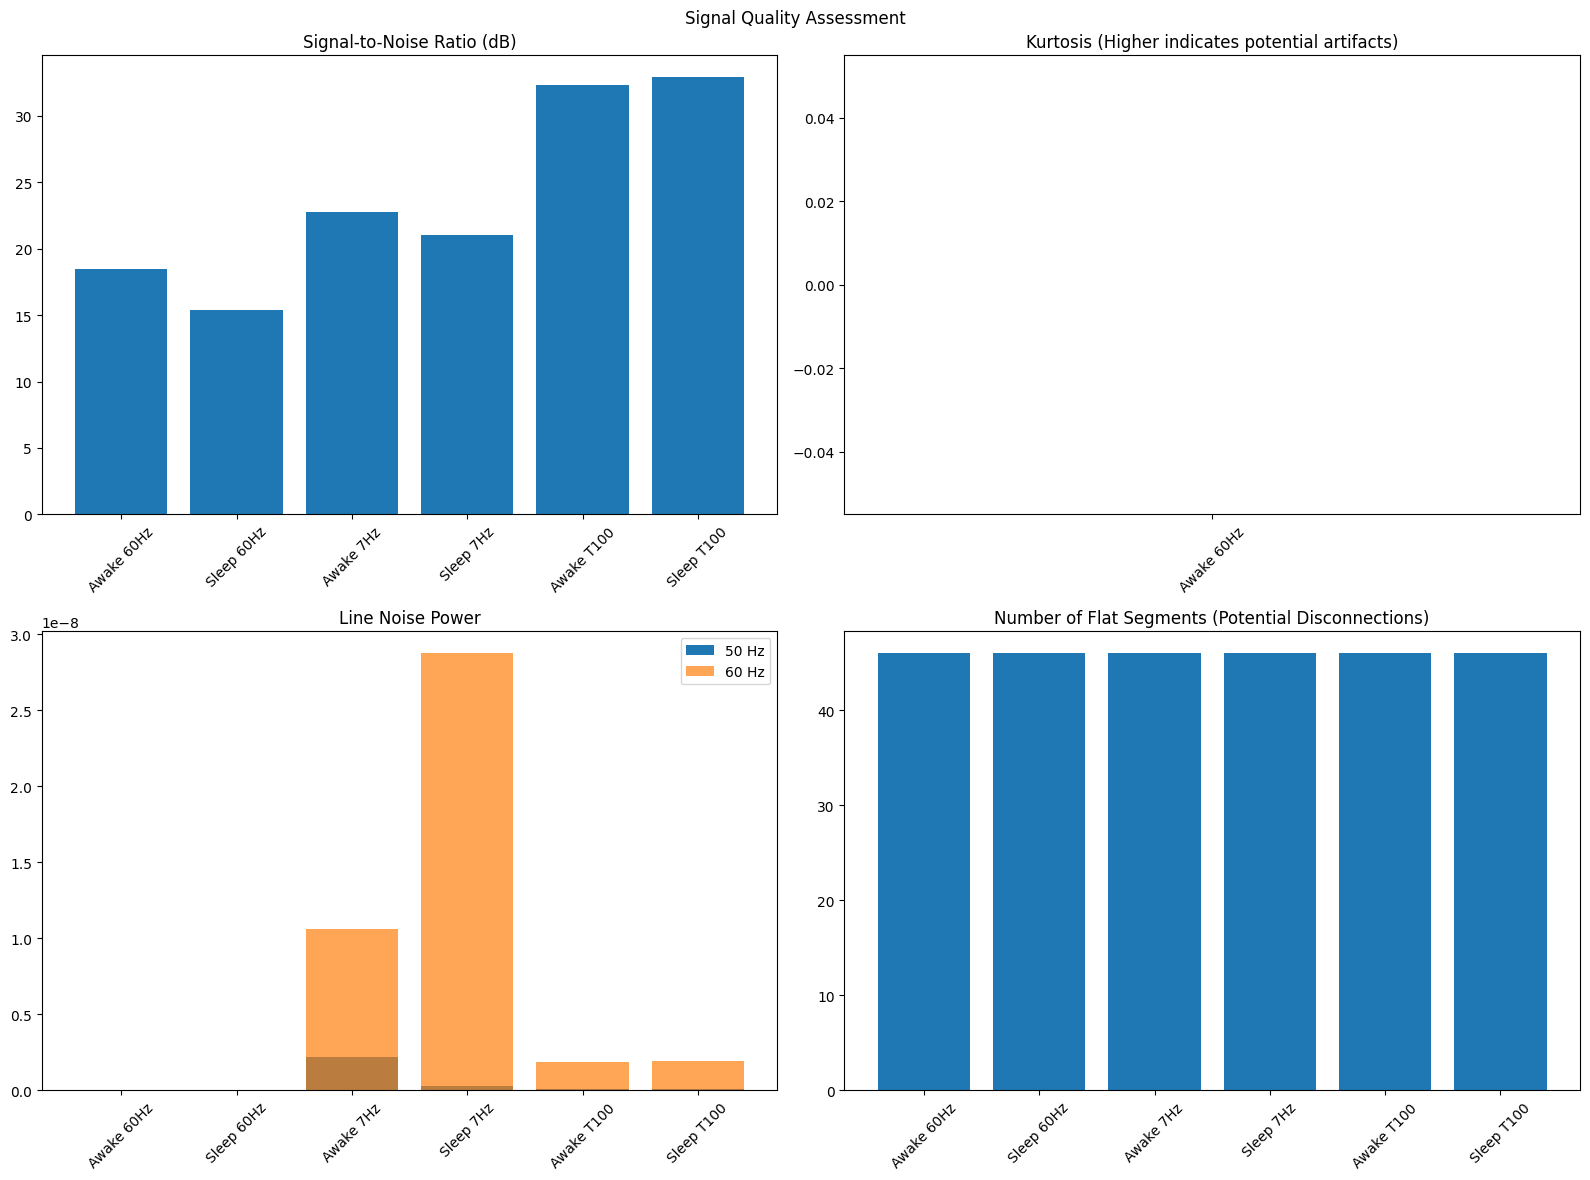

In [27]:
def assess_signal_quality(raw_list, labels):
    """Assess signal quality across different recordings"""
    metrics = []
    
    for raw in raw_list:
        data = raw.get_data()
        
        # Calculate SNR (approximation using std/mean)
        signal_power = np.var(data)
        noise_estimate = np.median(np.abs(data)) / 0.6745  # Robust estimate of noise
        snr = 10 * np.log10(signal_power / (noise_estimate**2)) if noise_estimate > 0 else float('inf')
        
        # Calculate kurtosis (measure of outliers/artifacts)
        kurt = scipy.stats.kurtosis(data, axis=1).mean()
        
        # Calculate line noise (power at 50/60 Hz)
        psd = raw.compute_psd(fmin=45, fmax=65)
        psds, freqs = psd.get_data(return_freqs=True)
        
        # Find indices closest to 50Hz and 60Hz
        idx_50 = np.argmin(np.abs(freqs - 50))
        idx_60 = np.argmin(np.abs(freqs - 60))
        
        power_50 = np.mean(psds[:, idx_50])
        power_60 = np.mean(psds[:, idx_60])
        
        # Number of flat segments (potential disconnections)
        diff = np.diff(data, axis=1)
        flat_mask = np.abs(diff) < 0.01
        flat_segments = np.sum(np.sum(flat_mask, axis=1) > 0.5 * diff.shape[1])
        
        metrics.append({
            'label': labels,
            'snr': snr,
            'kurtosis': kurt,
            'power_50hz': power_50,
            'power_60hz': power_60,
            'flat_segments': flat_segments
        })
    
    # Create quality visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot SNR
    axes[0, 0].bar(labels, [m['snr'] for m in metrics])
    axes[0, 0].set_title('Signal-to-Noise Ratio (dB)')
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot kurtosis
    axes[0, 1].bar(labels, [m['kurtosis'] for m in metrics])
    axes[0, 1].set_title('Kurtosis (Higher indicates potential artifacts)')
    axes[0, 1].tick_params(axis='x', rotation=45)
    
    # Plot 50/60 Hz power
    axes[1, 0].bar(labels, [m['power_50hz'] for m in metrics], label='50 Hz')
    axes[1, 0].bar(labels, [m['power_60hz'] for m in metrics], alpha=0.7, label='60 Hz')
    axes[1, 0].set_title('Line Noise Power')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].legend()
    
    # Plot flat segments
    axes[1, 1].bar(labels, [m['flat_segments'] for m in metrics])
    axes[1, 1].set_title('Number of Flat Segments (Potential Disconnections)')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Signal Quality Assessment')
    plt.tight_layout()
    plt.show()

# Import required library
import scipy.stats

# Assess signal quality
raw_list = [awake_60hz_clean, sleep_60hz_clean, awake_7hz, sleep_7hz, awake_t100, sleep_t100]
labels = ['Awake 60Hz', 'Sleep 60Hz', 'Awake 7Hz', 'Sleep 7Hz', 'Awake T100', 'Sleep T100']

assess_signal_quality(raw_list, labels)